# 3D Turbo Spin Echo — k-space ordering, contrast, and scan efficiency

This notebook extends the Day 1/Day 2 sequence-programming notebooks into a **3D TSE** sequence.

The goal is to make the key design choices visible:

- **ETL**: echoes / phase-encoding locations per excitation
- **TEeff**: which echo samples the center of k-space
- **ky-kz ordering**: how 3D phase-encoding locations are assigned to echoes
- **elliptical filtering**: how ky-kz corners can be skipped for efficiency
- **sequence export**: how an ordering table becomes a Pulseq `.seq` file


## Workshop flow: Learn → Design → Build → Simulate → Export / Scan

```text
Learn      → understand ETL, TEeff, ky-kz ordering, and elliptical filtering
Design     → translate hand problems into code and ordering tables
Build      → create RF, gradient, ADC, timing, shot, and echo structures
Simulate   → inspect the candidate sequence before writing a scanner file
Export     → write the .seq only after the candidate is approved
```


## What this notebook produces

By the end, you should have:

1. a 3D `ky-kz` phase-encoding grid,
2. four ordering options: inside-out, linear, TEeff-optimized, and elliptical-filtered,
3. a sequence-programming table with `shot`, `echo`, `ky`, `kz`, and `role`,
4. a candidate 3D TSE Pulseq sequence object,
5. a BrainWeb-like 3D simulation / inspection step,
6. a `.seq` file only if the candidate sequence is approved.


In [180]:
# Imports and helper settings

import os
import math
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

try:
    import pypulseq as pp
    HAVE_PYPULSEQ = True
except Exception as exc:
    HAVE_PYPULSEQ = False
    PYPULSEQ_IMPORT_ERROR = exc

try:
    import torch
    HAVE_TORCH = True
except Exception as exc:
    HAVE_TORCH = False
    TORCH_IMPORT_ERROR = exc

try:
    import MRzeroCore as mr0
    HAVE_MRZERO = True
except Exception as exc:
    HAVE_MRZERO = False
    MRZERO_IMPORT_ERROR = exc

print("3D TSE notebook imports")
print("-----------------------")
print("NumPy      :", np.__version__)
print("Matplotlib :", plt.matplotlib.__version__)
print("PyPulseq   :", "OK" if HAVE_PYPULSEQ else f"FAILED: {PYPULSEQ_IMPORT_ERROR!r}")
print("Torch      :", "OK" if HAVE_TORCH else f"FAILED: {TORCH_IMPORT_ERROR!r}")
print("MRZeroCore :", "OK" if HAVE_MRZERO else f"FAILED: {MRZERO_IMPORT_ERROR!r}")

plt.rcParams.update({"figure.figsize": (6, 4), "axes.grid": True})


3D TSE notebook imports
-----------------------
NumPy      : 1.26.4
Matplotlib : 3.11.1
PyPulseq   : OK
Torch      : OK
MRZeroCore : OK


In [181]:
# Core protocol parameters
# These are conservative, editable workshop defaults.
#
# Teaching choice for this version:
#   ETL = 4
#   echo_spacing = 10 ms
#   TEeff_target = 40 ms
#
# Why this default?
#   Echo 4 lands at 40 ms, so the T2w / TEeff example is clean.
#   The readout and prephaser durations are kept short enough that the
#   sequence can fit the 10 ms echo spacing without silently stretching it.
#
# Advanced exercise:
#   Try ETL = 8 later and examine what must change to keep timing feasible.

B0_T = 0.2516
GAMMA_HZ_PER_T = 42.576e6
f0_hz = B0_T * GAMMA_HZ_PER_T

# 3D matrix. Keep this modest for workshop simulation and timing sanity.
nx = 64      # readout points
ny = 32      # ky phase encodes
nz = 16      # kz phase encodes / partitions

# Field of view in meters.
# A 96 mm FOV gives a simple whole-brain-like teaching volume while keeping
# gradient areas modest for the 10 ms echo-spacing example.
fov_x_m = 96e-3
fov_y_m = 96e-3
fov_z_m = 96e-3

# TSE timing.
TR = 1000e-3
ETL = 4
echo_spacing = 10e-3
TEeff_target = 40e-3
TEeff = TEeff_target  # short alias used in some notes/discussions

# RF pulse widths from the RF calibration notebook.
rf90_duration = 150e-6
rf180_duration = 300e-6

# Gradient / ADC timing.
# These are deliberately compact so the textbook ETL=4, TEeff=40 ms example
# can fit inside a 10 ms echo spacing.
adc_duration = 3.0e-3
prephaser_duration = 1.0e-3
pe_duration = prephaser_duration
combined_rewinder_duration = prephaser_duration
final_rewinder_duration = combined_rewinder_duration
block_raster = 10e-6

# Small timing gaps. Set to zero for the first textbook-clean implementation.
# Add small gaps later only if the resulting minimum echo spacing remains feasible.
delay_180_to_pe = 0.0
delay_after_rewind_to_next_pre = 0.0

def round_to_raster(t, raster=block_raster):
    return np.round(t / raster) * raster

# K-space widths in cycles/m.
kx_width = nx / fov_x_m
ky_width = ny / fov_y_m
kz_width = nz / fov_z_m

# Approximate nominal resolution implied by matrix and FOV.
dx_mm = fov_x_m / nx * 1e3
dy_mm = fov_y_m / ny * 1e3
dz_mm = fov_z_m / nz * 1e3

print("Core protocol parameters")
print("------------------------")
print(f"B0             : {B0_T:.4f} T")
print(f"f0             : {f0_hz/1e6:.3f} MHz")
print(f"Matrix         : {nx} × {ny} × {nz}")
print(f"FOV            : {fov_x_m*1e3:.1f} × {fov_y_m*1e3:.1f} × {fov_z_m*1e3:.1f} mm")
print(f"Nominal voxels : {dx_mm:.2f} × {dy_mm:.2f} × {dz_mm:.2f} mm")
print(f"ETL            : {ETL}")
print(f"Echo spacing   : {echo_spacing*1e3:.2f} ms")
print(f"TEeff target   : {TEeff_target*1e3:.2f} ms")
print(f"TR             : {TR*1e3:.1f} ms")
print(f"RF 90 / 180 PW : {rf90_duration*1e6:.1f} / {rf180_duration*1e6:.1f} us")
print(f"ADC duration   : {adc_duration*1e3:.2f} ms")
print(f"Pre/PE duration: {prephaser_duration*1e3:.2f} ms")


Core protocol parameters
------------------------
B0             : 0.2516 T
f0             : 10.712 MHz
Matrix         : 64 × 32 × 16
FOV            : 96.0 × 96.0 × 96.0 mm
Nominal voxels : 1.50 × 3.00 × 6.00 mm
ETL            : 4
Echo spacing   : 10.00 ms
TEeff target   : 40.00 ms
TR             : 1000.0 ms
RF 90 / 180 PW : 150.0 / 300.0 us
ADC duration   : 3.00 ms
Pre/PE duration: 1.00 ms


## Learn: What changes when 2D TSE becomes 3D TSE?

A 2D TSE image fills a 2D k-space plane:

```text
kx = readout direction
ky = phase-encoding direction
```

A 3D TSE volume adds a second phase-encoding direction:

```text
kx = readout direction
ky = in-plane phase encoding
kz = partition / slab phase encoding
```

The scheduling question becomes:

```text
Which (ky, kz) point should be acquired at which echo?
```


## Learn: Echo train length controls how many ky-kz points are acquired per TR

In TSE, one excitation is followed by a train of refocusing pulses and echoes.

```text
90° — 180° — echo 1 — 180° — echo 2 — ... — 180° — echo ETL
```

Each echo can acquire one `kx` readout line at a chosen `(ky, kz)` location.

For the first workshop implementation, we use a **textbook-clean default**:

```text
ETL = 4
echo_spacing = 10 ms
TEeff_target = 40 ms
```

That gives the simple timing story:

```text
echo 1 → 10 ms
echo 2 → 20 ms
echo 3 → 30 ms
echo 4 → 40 ms  ← central k-space for the T2w / TEeff example
```

Longer echo trains are useful, but they are not free. The RF pulses, readout prephaser, phase encoders, ADC/readout, rewinders, and block raster must all fit inside the echo spacing.


## Learn: TEeff is where central k-space meets contrast

The center of k-space controls gross image signal and contrast.

```text
central ky-kz → contrast and overall brightness
outer ky-kz   → edges and fine detail
```

For TSE, echoes occur at different times. The key design question is:

```text
Which echo samples ky = 0, kz = 0?
```

That echo time is the **effective echo time**, or `TEeff`.

In this notebook, the default T2w teaching example puts the central `(ky, kz)` point on echo 4:

```text
TEeff_target = 40 ms
echo_spacing = 10 ms
center echo = 4
```


## Learn: ETL affects scan time, SNR, contrast, and feasibility

ETL is not just a speed knob.

Longer ETL:

- reduces the number of TRs,
- shortens scan time,
- but later echoes have lower signal due to T2 decay,
- assigns different k-space locations to different echo times,
- and requires more sequence events to fit into a repeated echo-spacing budget.

At **0.2516 T**, SNR is precious. Long echo trains can be efficient, but late-echo lines may become weak and more sensitive to gradient imperfections, eddy currents, and timing errors.

For the first-pass workshop sequence, we start with:

```text
ETL = 4
```

This is long enough to teach TEeff-centered ordering, but short enough to keep the timing and visualization manageable.


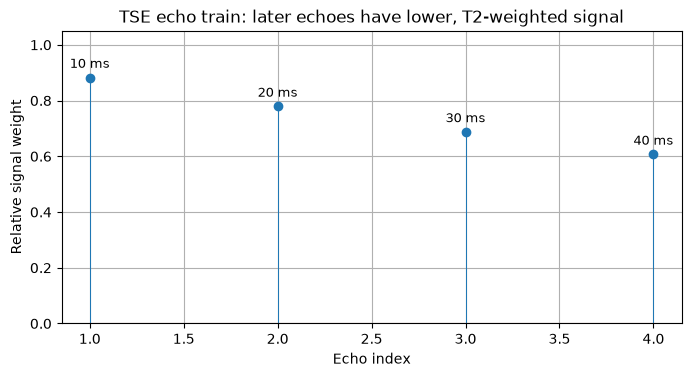

Echo train table
----------------
Echo  1: time =   10.0 ms | relative weight = 0.882
Echo  2: time =   20.0 ms | relative weight = 0.779
Echo  3: time =   30.0 ms | relative weight = 0.687
Echo  4: time =   40.0 ms | relative weight = 0.607


In [182]:
# Visualize: Echo train with T2-like signal decay

T2_assumed = 80e-3  # seconds; simple teaching value

echo_indices = np.arange(1, ETL + 1)
echo_times = echo_indices * echo_spacing
echo_weights = np.exp(-echo_times / T2_assumed)

plt.figure(figsize=(8, 3.8))
plt.stem(echo_indices, echo_weights)
plt.xlabel("Echo index")
plt.ylabel("Relative signal weight")
plt.title("TSE echo train: later echoes have lower, T2-weighted signal")
plt.ylim(0, 1.05)
for e, t, w in zip(echo_indices, echo_times, echo_weights):
    plt.text(e, w + 0.035, f"{t*1e3:.0f} ms", ha="center", fontsize=9)
plt.show()

print("Echo train table")
print("----------------")
for e, t, w in zip(echo_indices, echo_times, echo_weights):
    print(f"Echo {e:2d}: time = {t*1e3:6.1f} ms | relative weight = {w:.3f}")


## Design problem 1: How many ky-kz points do we need?

For full Cartesian 3D phase encoding:

```text
number of ky-kz points = ny × nz
```

Each ky-kz point corresponds to one readout line along `kx`.


In [183]:
# Code: Build the full ky-kz grid

ky_indices = np.arange(ny) - ny // 2
kz_indices = np.arange(nz) - nz // 2

delta_ky = 1 / fov_y_m
delta_kz = 1 / fov_z_m

ky_values = ky_indices * delta_ky
kz_values = kz_indices * delta_kz

KY, KZ = np.meshgrid(ky_values, kz_values, indexing="xy")
KYi, KZi = np.meshgrid(ky_indices, kz_indices, indexing="xy")

full_points = []
for iz in range(nz):
    for iy in range(ny):
        ky = float(KY[iz, iy])
        kz = float(KZ[iz, iy])
        full_points.append({
            "iy": int(iy),
            "iz": int(iz),
            "ky_index": int(KYi[iz, iy]),
            "kz_index": int(KZi[iz, iy]),
            "ky_cycles_per_m": ky,
            "kz_cycles_per_m": kz,
            "ky_cycles_per_mm": ky / 1000,
            "kz_cycles_per_mm": kz / 1000,
            "radius2_index": float(KYi[iz, iy]**2 + KZi[iz, iy]**2),
            "radius_index": float(np.sqrt(KYi[iz, iy]**2 + KZi[iz, iy]**2)),
        })

n_kykz = len(full_points)
print("Full 3D Cartesian ky-kz grid")
print("----------------------------")
print(f"ny × nz = {ny} × {nz} = {n_kykz} ky-kz points")
print(f"delta ky = {delta_ky/1000:.5f} cycles/mm")
print(f"delta kz = {delta_kz/1000:.5f} cycles/mm")
print(f"approx ky max = {np.max(np.abs(ky_values))/1000:.4f} cycles/mm")
print(f"approx kz max = {np.max(np.abs(kz_values))/1000:.4f} cycles/mm")


Full 3D Cartesian ky-kz grid
----------------------------
ny × nz = 32 × 16 = 512 ky-kz points
delta ky = 0.01042 cycles/mm
delta kz = 0.01042 cycles/mm
approx ky max = 0.1667 cycles/mm
approx kz max = 0.0833 cycles/mm


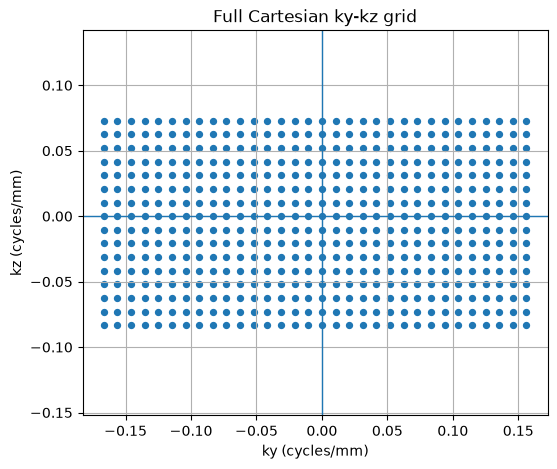

In [184]:
# Visualize: Full Cartesian ky-kz grid

plt.figure(figsize=(6, 5))
plt.scatter(KY.ravel()/1000, KZ.ravel()/1000, s=18)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("ky (cycles/mm)")
plt.ylabel("kz (cycles/mm)")
plt.title("Full Cartesian ky-kz grid")
plt.axis("equal")
plt.show()


## Design problem 2: Estimate scan time from ETL and TR

If each echo acquires one ky-kz point:

```text
shots = ceil(number of ky-kz points / ETL)
scan time ≈ shots × TR
```

For the default teaching protocol:

```text
ETL = 4
TR = 1 s
```

This is intentionally not the fastest possible protocol. It is a readable first implementation that makes the echo train, TEeff, and k-space ordering easy to inspect.


In [185]:
# Code: Compute shots and scan time

n_shots_full = int(np.ceil(n_kykz / ETL))
scan_time_full_s = n_shots_full * TR

print("Scan-time estimate")
print("------------------")
print(f"Full ky-kz points : {n_kykz}")
print(f"ETL               : {ETL}")
print(f"Shots / TRs       : {n_shots_full}")
print(f"TR                : {TR:.3f} s")
print(f"Scan time         : {scan_time_full_s:.1f} s = {scan_time_full_s/60:.2f} min")

print()
print("ETL comparison for the same ky-kz grid")
print("--------------------------------------")
for etl_test in [4, 8, 16]:
    shots_test = int(np.ceil(n_kykz / etl_test))
    scan_time_test = shots_test * TR
    last_echo_time_ms = etl_test * echo_spacing * 1e3
    print(
        f"ETL={etl_test:2d}: "
        f"shots={shots_test:4d}, "
        f"scan time={scan_time_test:6.1f} s, "
        f"last echo={last_echo_time_ms:5.1f} ms"
    )

print()
print("Teaching note")
print("-------------")
print("ETL=4 is the default because echo 4 lands at TEeff=40 ms with 10 ms spacing.")
print("ETL=8 or 16 can be explored later as an efficiency / feasibility exercise.")


Scan-time estimate
------------------
Full ky-kz points : 512
ETL               : 4
Shots / TRs       : 128
TR                : 1.000 s
Scan time         : 128.0 s = 2.13 min

ETL comparison for the same ky-kz grid
--------------------------------------
ETL= 4: shots= 128, scan time= 128.0 s, last echo= 40.0 ms
ETL= 8: shots=  64, scan time=  64.0 s, last echo= 80.0 ms
ETL=16: shots=  32, scan time=  32.0 s, last echo=160.0 ms

Teaching note
-------------
ETL=4 is the default because echo 4 lands at TEeff=40 ms with 10 ms spacing.
ETL=8 or 16 can be explored later as an efficiency / feasibility exercise.


## Design problem 3: Echo weights across the train

A simple teaching model for signal decay across the echo train is:

$S(e) = S_0 e^{-TE_e/T_2}$

where:

$TE_e = e \cdot \mathrm{echo\_spacing}$

This is not a full TSE signal model, but it shows the key idea:

```text
earlier echoes → stronger signal
later echoes   → lower signal and different contrast
```

For the default ETL=4 case, the last echo occurs at 40 ms. That lets us teach T2w/TEeff ordering without forcing a longer echo train that may not fit the 10 ms spacing.


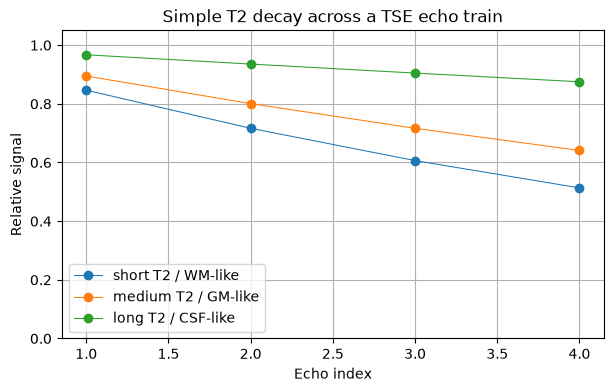

In [186]:
# Code: Compute simple echo-train signal weights

T2_examples = {
    "short T2 / WM-like": 60e-3,
    "medium T2 / GM-like": 90e-3,
    "long T2 / CSF-like": 300e-3,
}

plt.figure(figsize=(7, 4))
for label, T2 in T2_examples.items():
    weights = np.exp(-echo_times / T2)
    plt.plot(echo_indices, weights, marker="o", label=label)

plt.xlabel("Echo index")
plt.ylabel("Relative signal")
plt.title("Simple T2 decay across a TSE echo train")
plt.ylim(0, 1.05)
plt.legend()
plt.show()


## Design: A phase-encoding table is the bridge to sequence programming

The scanner does not receive the words “T1w”, “T2w”, or “elliptical”.

It receives a table like:

```text
shot | echo | ky | kz | role
```

So we will build several `ky_kz_table` options and visualize each one before using it to build the sequence.


In [187]:
# Helper functions for ordering tables

def assign_shot_echo(points, etl=ETL, name="ordering"):
    table = []
    for acq_idx, p in enumerate(points):
        q = dict(p)
        q["acq_idx"] = int(acq_idx)
        q["shot"] = int(acq_idx // etl)
        q["echo"] = int(acq_idx % etl + 1)
        q["echo_time_s"] = float((acq_idx % etl + 1) * echo_spacing)
        q["ordering"] = name
        if q["ky_index"] == 0 and q["kz_index"] == 0:
            q["role"] = "center"
        elif q["radius_index"] <= 2:
            q["role"] = "near-center"
        else:
            q["role"] = "outer"
        table.append(q)
    return table


def print_table_head(table, n=12):
    print("acq | shot | echo | ky_idx | kz_idx | ky cyc/mm | kz cyc/mm | role")
    print("----|------|------|--------|--------|-----------|-----------|------")
    for p in table[:n]:
        print(
            f"{p['acq_idx']:3d} | {p['shot']:4d} | {p['echo']:4d} | "
            f"{p['ky_index']:6d} | {p['kz_index']:6d} | "
            f"{p['ky_cycles_per_mm']:9.4f} | {p['kz_cycles_per_mm']:9.4f} | {p['role']}"
        )


def plot_ordering(table, title, color_by="acq_idx"):
    vals = np.array([p[color_by] for p in table], dtype=float)
    ky = np.array([p["ky_cycles_per_mm"] for p in table])
    kz = np.array([p["kz_cycles_per_mm"] for p in table])

    plt.figure(figsize=(6.2, 5.2))
    sc = plt.scatter(ky, kz, c=vals, s=24)
    plt.axhline(0, linewidth=1)
    plt.axvline(0, linewidth=1)
    plt.xlabel("ky (cycles/mm)")
    plt.ylabel("kz (cycles/mm)")
    plt.title(title)
    plt.axis("equal")
    cbar = plt.colorbar(sc)
    cbar.set_label(color_by)
    plt.show()


## Ordering 1: Inside-out / center-out ordering for T1w and early debug

Inside-out ordering sorts ky-kz points by distance from the center.

```text
central ky-kz first → then move outward
```

This is useful for T1w-like / early-echo-centered acquisitions and early debug scans.

Caution: inside-out ordering can jump around in ky-kz. On low-field systems with lower gradient performance, frequent polarity changes may be harder on the gradient chain.


In [188]:
# Ordering 1: Inside-out / center-out ordering

inside_out_points = sorted(
    full_points,
    key=lambda p: (p["radius2_index"], abs(p["kz_index"]), abs(p["ky_index"]), p["kz_index"], p["ky_index"])
)

ky_kz_table_inside_out = assign_shot_echo(inside_out_points, etl=ETL, name="inside_out")

print("Inside-out / center-out ordering")
print("--------------------------------")
print_table_head(ky_kz_table_inside_out, n=16)


Inside-out / center-out ordering
--------------------------------
acq | shot | echo | ky_idx | kz_idx | ky cyc/mm | kz cyc/mm | role
----|------|------|--------|--------|-----------|-----------|------
  0 |    0 |    1 |      0 |      0 |    0.0000 |    0.0000 | center
  1 |    0 |    2 |     -1 |      0 |   -0.0104 |    0.0000 | near-center
  2 |    0 |    3 |      1 |      0 |    0.0104 |    0.0000 | near-center
  3 |    0 |    4 |      0 |     -1 |    0.0000 |   -0.0104 | near-center
  4 |    1 |    1 |      0 |      1 |    0.0000 |    0.0104 | near-center
  5 |    1 |    2 |     -1 |     -1 |   -0.0104 |   -0.0104 | near-center
  6 |    1 |    3 |      1 |     -1 |    0.0104 |   -0.0104 | near-center
  7 |    1 |    4 |     -1 |      1 |   -0.0104 |    0.0104 | near-center
  8 |    2 |    1 |      1 |      1 |    0.0104 |    0.0104 | near-center
  9 |    2 |    2 |     -2 |      0 |   -0.0208 |    0.0000 | near-center
 10 |    2 |    3 |      2 |      0 |    0.0208 |    0.0000 | ne

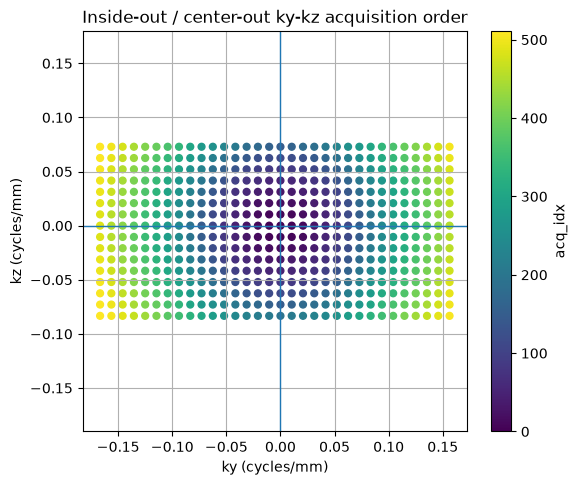

In [189]:
# Visualize: Inside-out ky-kz acquisition order

plot_ordering(ky_kz_table_inside_out, "Inside-out / center-out ky-kz acquisition order", color_by="acq_idx")


## Ordering 2: Linear ordering for predictable TSE acquisition

Linear ordering is simple and easy to debug.

```text
for kz from low to high:
    for ky from low to high:
        acquire one ky-kz point
```

The key question is not only the path, but **when central k-space appears in the echo train**.


In [190]:
# Ordering 2: Linear ordering

linear_points = sorted(full_points, key=lambda p: (p["kz_index"], p["ky_index"]))
ky_kz_table_linear = assign_shot_echo(linear_points, etl=ETL, name="linear")

print("Linear ordering")
print("---------------")
print_table_head(ky_kz_table_linear, n=16)

center_rows = [p for p in ky_kz_table_linear if p["ky_index"] == 0 and p["kz_index"] == 0]
if center_rows:
    c = center_rows[0]
    print("Central ky-kz in linear order:")
    print(f"  acq index : {c['acq_idx']}")
    print(f"  shot      : {c['shot']}")
    print(f"  echo      : {c['echo']}")
    print(f"  echo time : {c['echo_time_s']*1e3:.1f} ms")


Linear ordering
---------------
acq | shot | echo | ky_idx | kz_idx | ky cyc/mm | kz cyc/mm | role
----|------|------|--------|--------|-----------|-----------|------
  0 |    0 |    1 |    -16 |     -8 |   -0.1667 |   -0.0833 | outer
  1 |    0 |    2 |    -15 |     -8 |   -0.1562 |   -0.0833 | outer
  2 |    0 |    3 |    -14 |     -8 |   -0.1458 |   -0.0833 | outer
  3 |    0 |    4 |    -13 |     -8 |   -0.1354 |   -0.0833 | outer
  4 |    1 |    1 |    -12 |     -8 |   -0.1250 |   -0.0833 | outer
  5 |    1 |    2 |    -11 |     -8 |   -0.1146 |   -0.0833 | outer
  6 |    1 |    3 |    -10 |     -8 |   -0.1042 |   -0.0833 | outer
  7 |    1 |    4 |     -9 |     -8 |   -0.0938 |   -0.0833 | outer
  8 |    2 |    1 |     -8 |     -8 |   -0.0833 |   -0.0833 | outer
  9 |    2 |    2 |     -7 |     -8 |   -0.0729 |   -0.0833 | outer
 10 |    2 |    3 |     -6 |     -8 |   -0.0625 |   -0.0833 | outer
 11 |    2 |    4 |     -5 |     -8 |   -0.0521 |   -0.0833 | outer
 12 |    3 |    1

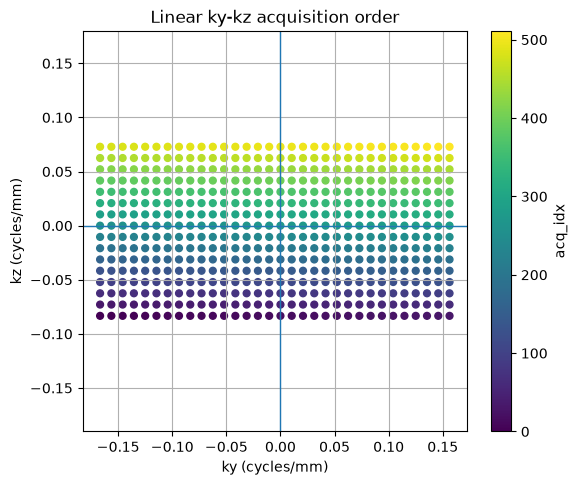

In [191]:
# Visualize: Linear ky-kz acquisition order

plot_ordering(ky_kz_table_linear, "Linear ky-kz acquisition order", color_by="acq_idx")


## Ordering 3: TEeff-optimized ordering for T2w contrast

For T2w TSE, the goal is often:

```text
place central ky-kz near TEeff
```

With the default teaching protocol:

```text
ETL = 4
echo_spacing = 10 ms
TEeff_target = 40 ms
```

central k-space should be assigned to **echo 4**.

We choose the echo index closest to the requested `TEeff_target`, then assign central k-space to that echo number within each shot when possible.


In [192]:
# Ordering 3: TEeff-optimized ordering for T2w contrast

center_echo = int(np.argmin(np.abs(echo_times - TEeff_target)) + 1)
realized_TEff_design = center_echo * echo_spacing

print("TEeff optimization")
print("------------------")
print(f"Total ky-kz points   : {len(full_points)}")
print(f"ETL                  : {ETL}")
print(f"TEeff target         : {TEeff_target*1e3:.1f} ms")
print(f"Echo spacing         : {echo_spacing*1e3:.1f} ms")
print(f"Selected center echo : {center_echo}")
print(f"Realized TEeff       : {realized_TEff_design * 1e3:.1f} ms")

if center_echo != ETL:
    print()
    print("NOTE: For the default textbook example we expect center_echo = ETL = 4.")
    print("      If you changed ETL or echo_spacing, check whether the design still matches the lecture.")

radial_points = sorted(
    full_points,
    key=lambda p: (p["radius2_index"], abs(p["kz_index"]), abs(p["ky_index"]), p["kz_index"], p["ky_index"])
)

# Assign the most central points first, but place them at the TEeff echo slot.
echo_slot_order = [center_echo]
for offset in range(1, ETL + 1):
    for e in (center_echo - offset, center_echo + offset):
        if 1 <= e <= ETL and e not in echo_slot_order:
            echo_slot_order.append(e)
print("TEeff echo slot order:", echo_slot_order)

n_shots_te = int(np.ceil(len(radial_points) / ETL))
print(f"TEeff-optimized shots / TRs: {n_shots_te}")
te_points_with_slots = []
idx = 0
for shot in range(n_shots_te):
    for echo in echo_slot_order:
        if idx >= len(radial_points):
            break
        p = dict(radial_points[idx])
        p["shot"] = int(shot)
        p["echo"] = int(echo)
        p["echo_time_s"] = float(echo * echo_spacing)
        p["ordering"] = "TEeff_optimized"
        p["acq_idx"] = int(shot * ETL + (echo - 1))
        if p["ky_index"] == 0 and p["kz_index"] == 0:
            p["role"] = "center / TEeff"
        elif p["radius_index"] <= 2:
            p["role"] = "near-center"
        else:
            p["role"] = "outer"
        te_points_with_slots.append(p)
        idx += 1

ky_kz_table_teff = sorted(te_points_with_slots, key=lambda p: (p["shot"], p["echo"]))

print("TEeff-optimized ordering table head")
print("-----------------------------------")
print_table_head(ky_kz_table_teff, n=25)

center_rows = [p for p in ky_kz_table_teff if p["ky_index"] == 0 and p["kz_index"] == 0]
if center_rows:
    c = center_rows[0]
    print("Central ky-kz:")
    print(f"  shot      : {c['shot']}")
    print(f"  echo      : {c['echo']}")
    print(f"  TEeff     : {c['echo_time_s']*1e3:.1f} ms")


TEeff optimization
------------------
Total ky-kz points   : 512
ETL                  : 4
TEeff target         : 40.0 ms
Echo spacing         : 10.0 ms
Selected center echo : 4
Realized TEeff       : 40.0 ms
TEeff echo slot order: [4, 3, 2, 1]
TEeff-optimized shots / TRs: 128
TEeff-optimized ordering table head
-----------------------------------
acq | shot | echo | ky_idx | kz_idx | ky cyc/mm | kz cyc/mm | role
----|------|------|--------|--------|-----------|-----------|------
  0 |    0 |    1 |      0 |     -1 |    0.0000 |   -0.0104 | near-center
  1 |    0 |    2 |      1 |      0 |    0.0104 |    0.0000 | near-center
  2 |    0 |    3 |     -1 |      0 |   -0.0104 |    0.0000 | near-center
  3 |    0 |    4 |      0 |      0 |    0.0000 |    0.0000 | center / TEeff
  4 |    1 |    1 |     -1 |      1 |   -0.0104 |    0.0104 | near-center
  5 |    1 |    2 |      1 |     -1 |    0.0104 |   -0.0104 | near-center
  6 |    1 |    3 |     -1 |     -1 |   -0.0104 |   -0.0104 | near-ce

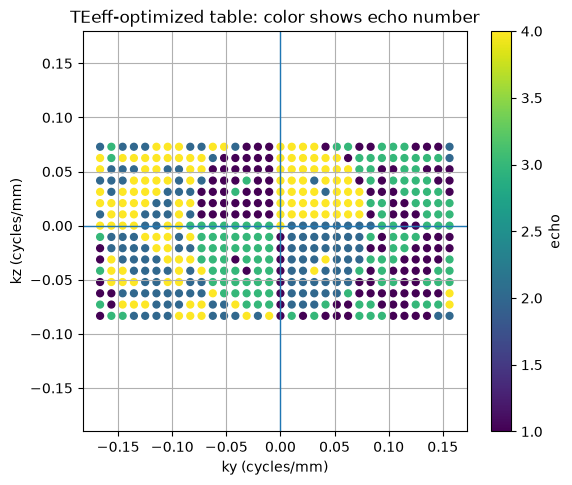

In [193]:
# Visualize: TEeff-optimized echo assignment

plot_ordering(ky_kz_table_teff, "TEeff-optimized table: color shows echo number", color_by="echo")


## Ordering 4: Elliptical ky-kz filtering for scan efficiency

Filtering and ordering are different choices.

```text
Filtering says: which ky-kz points do we acquire?
Ordering says : when do we acquire those points?
```

Elliptical filtering keeps the center and skips the ky-kz corners:

$\left(\frac{ky}{ky_{\max}}\right)^2 + \left(\frac{kz}{kz_{\max}}\right)^2 \leq 1$

The far corners of ky-kz often carry less signal energy, while still costing scan time.


In [194]:
# Ordering 4: Elliptical ky-kz filtering

kymax = np.max(np.abs(ky_values))
kzmax = np.max(np.abs(kz_values))

ellipse_points = []
skipped_points = []
for p in full_points:
    rho2 = (p["ky_cycles_per_m"] / kymax)**2 + (p["kz_cycles_per_m"] / kzmax)**2
    q = dict(p)
    q["rho2"] = float(rho2)
    if rho2 <= 1.0:
        ellipse_points.append(q)
    else:
        skipped_points.append(q)

ellipse_inside_out_points = sorted(
    ellipse_points,
    key=lambda p: (p["radius2_index"], abs(p["kz_index"]), abs(p["ky_index"]), p["kz_index"], p["ky_index"])
)

ky_kz_table_ellipse = assign_shot_echo(ellipse_inside_out_points, etl=ETL, name="ellipse_inside_out")

print("Elliptical filtering")
print("--------------------")
print(f"Full points      : {len(full_points)}")
print(f"Acquired points  : {len(ellipse_points)}")
print(f"Skipped points   : {len(skipped_points)}")
print(f"Acquired fraction: {len(ellipse_points)/len(full_points):.3f}")
print_table_head(ky_kz_table_ellipse, n=16)


Elliptical filtering
--------------------
Full points      : 512
Acquired points  : 391
Skipped points   : 121
Acquired fraction: 0.764
acq | shot | echo | ky_idx | kz_idx | ky cyc/mm | kz cyc/mm | role
----|------|------|--------|--------|-----------|-----------|------
  0 |    0 |    1 |      0 |      0 |    0.0000 |    0.0000 | center
  1 |    0 |    2 |     -1 |      0 |   -0.0104 |    0.0000 | near-center
  2 |    0 |    3 |      1 |      0 |    0.0104 |    0.0000 | near-center
  3 |    0 |    4 |      0 |     -1 |    0.0000 |   -0.0104 | near-center
  4 |    1 |    1 |      0 |      1 |    0.0000 |    0.0104 | near-center
  5 |    1 |    2 |     -1 |     -1 |   -0.0104 |   -0.0104 | near-center
  6 |    1 |    3 |      1 |     -1 |    0.0104 |   -0.0104 | near-center
  7 |    1 |    4 |     -1 |      1 |   -0.0104 |    0.0104 | near-center
  8 |    2 |    1 |      1 |      1 |    0.0104 |    0.0104 | near-center
  9 |    2 |    2 |     -2 |      0 |   -0.0208 |    0.0000 | near-c

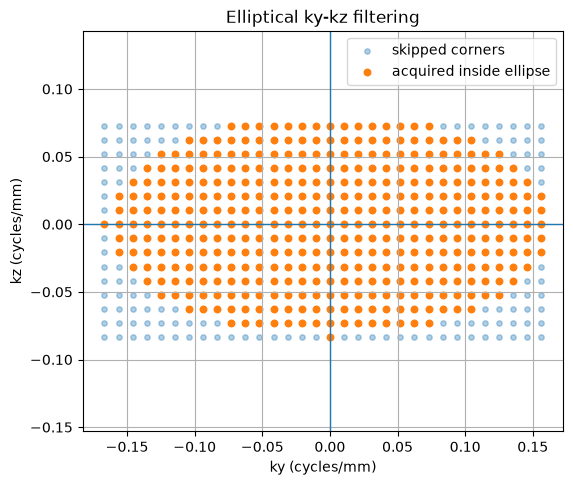

In [195]:
# Visualize: Elliptical mask — acquired center, skipped corners

plt.figure(figsize=(6.2, 5.2))
if skipped_points:
    plt.scatter(
        [p["ky_cycles_per_mm"] for p in skipped_points],
        [p["kz_cycles_per_mm"] for p in skipped_points],
        s=15,
        label="skipped corners",
        alpha=0.35,
    )
plt.scatter(
    [p["ky_cycles_per_mm"] for p in ellipse_points],
    [p["kz_cycles_per_mm"] for p in ellipse_points],
    s=22,
    label="acquired inside ellipse",
)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("ky (cycles/mm)")
plt.ylabel("kz (cycles/mm)")
plt.title("Elliptical ky-kz filtering")
plt.legend()
plt.axis("equal")
plt.show()


In [196]:
# Compare: Full versus elliptical scan time

n_shots_ellipse = int(np.ceil(len(ky_kz_table_ellipse) / ETL))
scan_time_ellipse_s = n_shots_ellipse * TR

print("Full versus elliptical scan-time estimate")
print("------------------------------------------")
print(f"Full points              : {len(full_points)}")
print(f"Elliptical points        : {len(ky_kz_table_ellipse)}")
print(f"ETL                      : {ETL}")
print(f"Full shots               : {n_shots_full}")
print(f"Elliptical shots         : {n_shots_ellipse}")
print(f"Full scan time           : {scan_time_full_s:.1f} s")
print(f"Elliptical scan time     : {scan_time_ellipse_s:.1f} s")
print(f"Estimated time savings   : {(1 - scan_time_ellipse_s/scan_time_full_s)*100:.1f}%")


Full versus elliptical scan-time estimate
------------------------------------------
Full points              : 512
Elliptical points        : 391
ETL                      : 4
Full shots               : 128
Elliptical shots         : 98
Full scan time           : 128.0 s
Elliptical scan time     : 98.0 s
Estimated time savings   : 23.4%


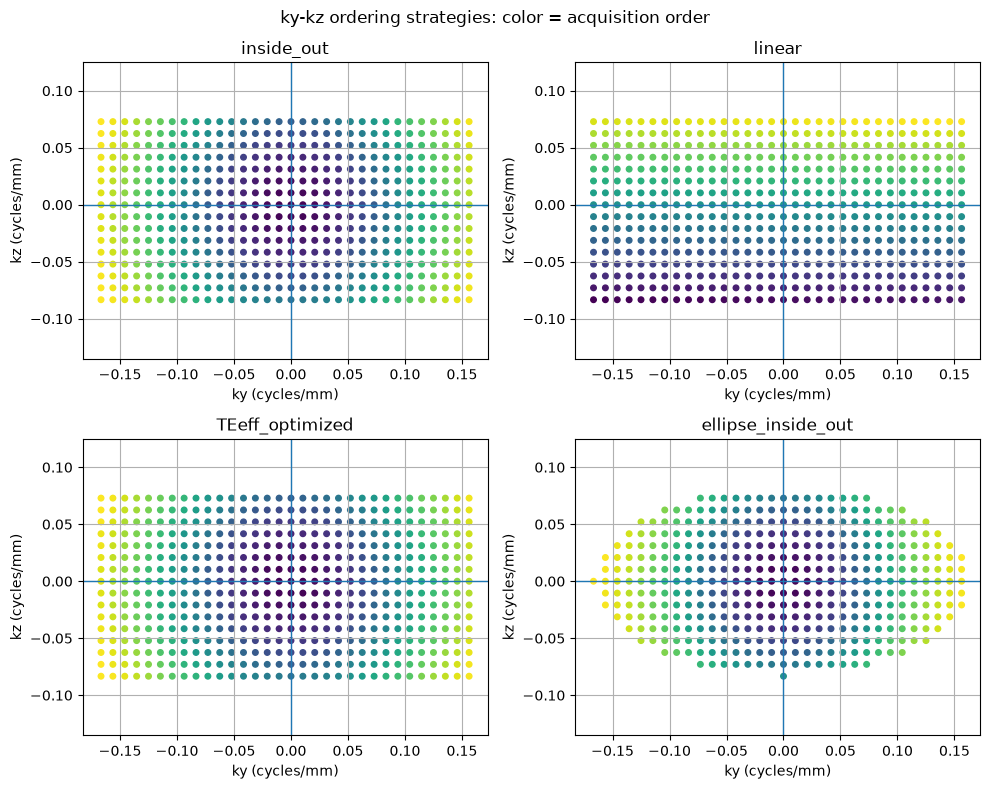

In [197]:
# Visualize: Side-by-side comparison of all ordering strategies

ordering_tables = {
    "inside_out": ky_kz_table_inside_out,
    "linear": ky_kz_table_linear,
    "TEeff_optimized": ky_kz_table_teff,
    "ellipse_inside_out": ky_kz_table_ellipse,
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (name, table) in zip(axes.ravel(), ordering_tables.items()):
    ky = np.array([p["ky_cycles_per_mm"] for p in table])
    kz = np.array([p["kz_cycles_per_mm"] for p in table])
    val = np.array([p["acq_idx"] for p in table])
    ax.scatter(ky, kz, c=val, s=16)
    ax.axhline(0, linewidth=1)
    ax.axvline(0, linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("ky (cycles/mm)")
    ax.set_ylabel("kz (cycles/mm)")
    ax.axis("equal")

plt.suptitle("ky-kz ordering strategies: color = acquisition order")
plt.tight_layout()
plt.show()


## Build: events for the 3D TSE sequence

Now we switch from design tables to Pulseq sequence programming.

The compact educational sequence uses:

```text
RF 90° excitation
RF 180° refocusing pulses
Gx readout + ADC
Gx readout prephaser before the 180° pulse
Gy / Gz phase-encoding gradients
Gy / Gz phase-encoding rewinders
```

For this first-pass notebook, the default timing is deliberately modest:

```text
ETL = 4
echo_spacing = 10 ms
TEeff_target = 40 ms
ADC duration = 3 ms
prephaser / phase-encode duration = 1 ms
```

This keeps the default sequence close to the lecture example and avoids silently stretching the echo spacing. Scanner deployment still requires local safety and hardware validation.


In [198]:
# Build: Scanner limits and Pulseq system settings

if not HAVE_PYPULSEQ:
    raise ImportError(f"PyPulseq is required for sequence export. Import error: {PYPULSEQ_IMPORT_ERROR!r}")

system = pp.Opts(
    max_grad=10,
    grad_unit="mT/m",
    max_slew=50,
    slew_unit="T/m/s",
    rf_ringdown_time=20e-6,
    rf_dead_time=100e-6,
    adc_dead_time=10e-6,
)

print("Pulseq system created")
print("---------------------")
print(system)


Pulseq system created
---------------------
System limits:
max_grad: 425760.0
max_slew: 2128800000
rise_time: None
rf_dead_time: 0.0001
rf_ringdown_time: 2e-05
adc_dead_time: 1e-05
adc_raster_time: 1e-07
rf_raster_time: 1e-06
grad_raster_time: 1e-05
block_duration_raster: 1e-05
adc_samples_limit: 0
adc_samples_divisor: 4
gamma: 42576000
B0: 1.5


In [199]:
# Build: RF events — 90° excitation and 180° refocusing train

rf90 = pp.make_block_pulse(
    flip_angle=np.pi / 2,
    duration=rf90_duration,
    phase_offset=0.0,          # 90x
    delay=system.rf_dead_time,
    system=system,
)

rf180 = pp.make_block_pulse(
    flip_angle=np.pi,
    duration=rf180_duration,
    phase_offset=np.pi / 2,    # 180y
    delay=system.rf_dead_time,
    system=system,
)

print("RF events")
print("---------")
print(f"90x duration  : {rf90_duration*1e6:.1f} us")
print(f"180y duration : {rf180_duration*1e6:.1f} us")


RF events
---------
90x duration  : 150.0 us
180y duration : 300.0 us


In [ ]:
# Build: Readout gradient and ADC
#
# The readout duration must satisfy two raster constraints:
#
#   1. ADC dwell raster:
#        adc_dwell = adc_duration / nx
#        must be an integer multiple of system.adc_raster_time
#
#   2. Gradient raster:
#        gx flat_time = adc_duration
#        must be an integer multiple of system.grad_raster_time
#
# The previous fix made the ADC dwell valid but produced:
#
#   adc_duration = 3.0016 ms
#
# which is not valid for the gradient raster. This cell chooses a readout
# duration that is valid for both ADC and gradient timing.

print("Build readout gradient and ADC")
print("------------------------------")

# Raster times from PyPulseq system.
adc_raster_time = float(getattr(system, "adc_raster_time", 100e-9))
grad_raster_time = float(getattr(system, "grad_raster_time", 10e-6))
block_raster_time = float(getattr(system, "block_duration_raster", 10e-6))

# Requested readout duration from the protocol cell.
adc_duration_requested = float(adc_duration)

print("Raster constraints")
print("------------------")
print(f"ADC raster time        : {adc_raster_time*1e9:.1f} ns")
print(f"Gradient raster time   : {grad_raster_time*1e6:.1f} µs")
print(f"Block raster time      : {block_raster_time*1e6:.1f} µs")
print(f"Requested duration     : {adc_duration_requested*1e3:.6f} ms")
print(f"ADC samples            : {nx}")

# ------------------------------------------------------------
# Find the nearest readout duration that is valid for both:
#
#   adc_duration = nx * adc_dwell
#   adc_dwell = integer * adc_raster_time
#   adc_duration = integer * grad_raster_time
#
# We search upward from the requested duration so the readout does not
# become shorter than requested.
# ------------------------------------------------------------

def is_close_to_integer(x, tol=1e-9):
    return abs(x - round(x)) < tol

duration_candidate = adc_duration_requested
max_search_steps = 200000

adc_duration = None
adc_dwell = None

# Step in ADC raster dwell units.
# Each increment changes total duration by nx * adc_raster_time.
duration_step_from_adc = nx * adc_raster_time

start_n = int(np.ceil(adc_duration_requested / duration_step_from_adc))

for n in range(start_n, start_n + max_search_steps):

    candidate = n * duration_step_from_adc

    adc_dwell_candidate = candidate / nx

    adc_ok = is_close_to_integer(adc_dwell_candidate / adc_raster_time)
    grad_ok = is_close_to_integer(candidate / grad_raster_time)
    block_ok = is_close_to_integer(candidate / block_raster_time)

    if adc_ok and grad_ok and block_ok:
        adc_duration = float(candidate)
        adc_dwell = float(adc_dwell_candidate)
        break

if adc_duration is None:
    raise RuntimeError(
        "Could not find a readout duration satisfying ADC, gradient, and block rasters. "
        "Try changing nx or the requested adc_duration."
    )

print()
print("Raster-aligned readout")
print("----------------------")
print(f"Requested ADC duration       : {adc_duration_requested*1e3:.6f} ms")
print(f"Raster-aligned ADC duration  : {adc_duration*1e3:.6f} ms")
print(f"Duration change              : {(adc_duration - adc_duration_requested)*1e6:.3f} µs")
print(f"Raster-aligned ADC dwell     : {adc_dwell*1e6:.6f} µs")
print(f"ADC dwell / adc raster       : {adc_dwell / adc_raster_time:.0f}")
print(f"ADC duration / grad raster   : {adc_duration / grad_raster_time:.0f}")
print(f"ADC duration / block raster  : {adc_duration / block_raster_time:.0f}")

# Readout gradient traverses kx during ADC.
# The flat area sets the total kx width sampled during readout.
gx = pp.make_trapezoid(
    channel="x",
    flat_area=kx_width,
    flat_time=adc_duration,
    system=system,
)

adc = pp.make_adc(
    num_samples=nx,
    dwell=adc_dwell,
    delay=0,
    system=system,
)

# Actual readout block duration includes gradient ramps.
gx_duration = pp.calc_duration(gx)
adc_event_duration = pp.calc_duration(adc)
readout_block_duration = max(gx_duration, adc_event_duration)

print()
print("Readout created")
print("---------------")
print(f"Readout direction            : x")
print(f"ADC samples                  : {nx}")
print(f"ADC dwell                    : {adc_dwell*1e6:.6f} µs")
print(f"ADC duration                 : {adc_duration*1e3:.6f} ms")
print(f"Gx flat time                 : {gx.flat_time*1e3:.6f} ms")
print(f"Gx full duration             : {gx_duration*1e3:.6f} ms")
print(f"Readout block duration       : {readout_block_duration*1e3:.6f} ms")
print(f"kx width                     : {kx_width:.1f} cycles/m")

Build readout gradient and ADC
------------------------------
ADC raster time             : 100.0 ns
Requested ADC duration      : 3.000000 ms
Requested ADC dwell         : 46.875000 µs
Raster-aligned ADC dwell    : 46.900000 µs
Raster-aligned ADC duration : 3.001600 ms
ADC duration change         : 1.600 µs

Readout created.
Readout direction           : x
ADC samples                 : 64
ADC dwell                   : 46.900000 µs
ADC duration                : 3.001600 ms
kx width                    : 666.7 cycles/m


/var/folders/8h/lmr4n2c97d9fk8tvy0k446tw0000gq/T/ipykernel_83596/3669625877.py:46: UserWarning: Specified ADC delay 0.00 us is less than the dead time 10 us. Delay was increased to the dead time.
  adc = pp.make_adc(


In [201]:
# Build: Readout prephaser
#
# Spin-echo convention used in this notebook:
#   A physical +Gx_pre placed BEFORE the 180° pulse behaves like an
#   effective -kx prephaser at the readout because the 180° pulse refocuses
#   the accumulated phase.

# Physical prephaser area before 180°.
gx_pre = pp.make_trapezoid(
    channel="x",
    area=kx_width / 2,
    duration=prephaser_duration,
    system=system,
)

print("Readout prephaser")
print("-----------------")
print(f"physical gx_pre area before 180 : {kx_width/2/1000:.4f} cycles/mm")
print(f"effective readout start         : {-kx_width/2/1000:.4f} cycles/mm")
print(f"duration                        : {prephaser_duration*1e3:.3f} ms")

Readout prephaser
-----------------
physical gx_pre area before 180 : 0.3333 cycles/mm
effective readout start         : -0.3333 cycles/mm
duration                        : 1.000 ms


In [202]:
# Build: Phase-encoding gradients Gy and Gz

pe_duration = prephaser_duration

def make_phase_encode_gradients(ky_cycles_per_m, kz_cycles_per_m):
    gy = pp.make_trapezoid(
        channel="y",
        area=float(ky_cycles_per_m),
        duration=pe_duration,
        system=system,
    )
    gz = pp.make_trapezoid(
        channel="z",
        area=float(kz_cycles_per_m),
        duration=pe_duration,
        system=system,
    )
    return gy, gz

print("Phase-encoding gradient helper ready")
print("------------------------------------")
print(f"PE duration : {pe_duration*1e3:.3f} ms")
print(f"ky range    : {ky_values[0]/1000:.4f} to {ky_values[-1]/1000:.4f} cycles/mm")
print(f"kz range    : {kz_values[0]/1000:.4f} to {kz_values[-1]/1000:.4f} cycles/mm")


Phase-encoding gradient helper ready
------------------------------------
PE duration : 1.000 ms
ky range    : -0.1667 to 0.1562 cycles/mm
kz range    : -0.0833 to 0.0729 cycles/mm


In [203]:
# Build: Timing model for echo spacing and TEeff
#
# This timing model checks whether the default ETL=4, echo_spacing=10 ms,
# TEeff=40 ms example can be assembled without echo-to-echo drift.
#
# Educational 3D TSE structure:
#
#   90x
#   for each echo:
#       +Gx_pre before 180
#       delay to place 180 center correctly
#       180y
#       Gy/Gz phase encoding
#       delay to place ADC center correctly
#       Gx readout + ADC
#       Gx/Gy/Gz rewinders
#
# Spin-echo convention:
#   Physical +Gx_pre before the 180° pulse behaves like an effective
#   -kx prephaser at the readout because the 180° refocuses phase.

print("Timing model for 3D TSE")
print("-----------------------")

# ----------------------------
# Helper timing functions
# ----------------------------

def ceil_to_raster(t, raster=block_raster):
    """Round a duration up to the block raster."""
    return np.ceil(t / raster) * raster


def event_duration(event):
    """Return the Pulseq event duration in seconds."""
    return float(pp.calc_duration(event))


def block_duration(*events):
    """Return the duration of a Pulseq block containing one or more events."""
    if not events:
        return 0.0
    return max(event_duration(ev) for ev in events if ev is not None)


def rf_center_offset(rf_event, nominal_duration=None):
    """Approximate RF center relative to the start of its Pulseq block."""
    delay = float(getattr(rf_event, "delay", 0.0))
    if nominal_duration is not None:
        dur = float(nominal_duration)
    elif hasattr(rf_event, "shape_dur"):
        dur = float(rf_event.shape_dur)
    elif hasattr(rf_event, "duration"):
        dur = float(rf_event.duration)
    else:
        dur = max(0.0, event_duration(rf_event) - delay)
    return delay + dur / 2


def adc_center_offset(adc_event):
    """ADC center relative to the start of the readout block."""
    delay = float(getattr(adc_event, "delay", 0.0))
    dur = float(getattr(adc_event, "duration", adc_duration))
    return delay + dur / 2


# ----------------------------
# Timing gaps and rewinder duration
# ----------------------------
# Use the compact default gaps from the protocol cell unless the user edited them.
delay_180_to_pe = round_to_raster(globals().get("delay_180_to_pe", 0.0))
delay_after_rewind_to_next_pre = round_to_raster(globals().get("delay_after_rewind_to_next_pre", 0.0))

combined_rewinder_duration = round_to_raster(globals().get(
    "combined_rewinder_duration",
    globals().get("final_rewinder_duration", prephaser_duration),
))
final_rewinder_duration = combined_rewinder_duration
rewinder_duration = combined_rewinder_duration

# ----------------------------
# Actual block durations
# ----------------------------

rf90_block_duration = event_duration(rf90)
rf180_block_duration = event_duration(rf180)
rf90_center_in_block = rf_center_offset(rf90, rf90_duration)
rf180_center_in_block = rf_center_offset(rf180, rf180_duration)

gx_pre_block_duration = event_duration(gx_pre)
pe_block_duration = pe_duration
readout_block_duration = block_duration(gx, adc)
adc_center_in_readout_block = adc_center_offset(adc)

# Representative readout rewinder used only to estimate timing.
gx_rewind_for_timing = pp.make_trapezoid(
    channel="x",
    area=-kx_width / 2,
    duration=combined_rewinder_duration,
    system=system,
)
rewind_block_duration = max(event_duration(gx_rewind_for_timing), combined_rewinder_duration, pe_duration)

# ----------------------------
# Minimum echo-spacing budget
# ----------------------------
# These are the three timing constraints that must fit:
#   1. RF90 center -> RF180 center for echo 1
#   2. RF180 center -> ADC center for every echo
#   3. ADC center -> next RF180 center between echoes

min_es_first_180 = 2 * (
    rf90_block_duration
    + gx_pre_block_duration
    + rf180_center_in_block
    - rf90_center_in_block
)

min_es_180_to_adc = 2 * (
    rf180_block_duration
    - rf180_center_in_block
    + delay_180_to_pe
    + pe_block_duration
    + adc_center_in_readout_block
)

min_es_between_echoes = 2 * (
    readout_block_duration
    - adc_center_in_readout_block
    + rewind_block_duration
    + delay_after_rewind_to_next_pre
    + gx_pre_block_duration
    + rf180_center_in_block
)

minimum_echo_spacing = ceil_to_raster(max(
    min_es_first_180,
    min_es_180_to_adc,
    min_es_between_echoes,
))

# For this notebook version, the default parameters should make the requested
# echo spacing feasible. We do not silently stretch echo spacing; if the user
# edits parameters and breaks feasibility, the build cell should not proceed.
echo_spacing_requested = echo_spacing
echo_spacing_used = echo_spacing_requested
realized_echo_spacing = echo_spacing_used

if minimum_echo_spacing > echo_spacing_requested + 1e-12:
    timing_ok = False
else:
    timing_ok = True

# Echo-time table within one echo train.
echo_indices = np.arange(1, ETL + 1)
echo_times_used = echo_indices * echo_spacing_used
center_echo_index = int(np.argmin(np.abs(echo_times_used - TEeff_target))) + 1
center_echo = center_echo_index
realized_TEff = center_echo_index * echo_spacing_used

print(f"Requested echo spacing          : {echo_spacing_requested*1e3:.3f} ms")
print(f"Minimum feasible echo spacing   : {minimum_echo_spacing*1e3:.3f} ms")
print(f"Echo spacing used for build     : {echo_spacing_used*1e3:.3f} ms")

print()
print(f"ETL                             : {ETL}")
print(f"Requested TEeff                 : {TEeff_target*1e3:.3f} ms")
print(f"Center echo index               : {center_echo_index}")
print(f"Realized TEeff                  : {realized_TEff*1e3:.3f} ms")
print(f"TEeff error                     : {(realized_TEff - TEeff_target)*1e3:.3f} ms")

print()
print("Block durations used for scheduling")
print("-----------------------------------")
print(f"RF90 block duration             : {rf90_block_duration*1e3:.3f} ms")
print(f"RF90 center offset              : {rf90_center_in_block*1e3:.3f} ms")
print(f"Gx_pre block duration           : {gx_pre_block_duration*1e3:.3f} ms")
print(f"RF180 block duration            : {rf180_block_duration*1e3:.3f} ms")
print(f"RF180 center offset             : {rf180_center_in_block*1e3:.3f} ms")
print(f"delay_180_to_pe                 : {delay_180_to_pe*1e3:.3f} ms")
print(f"Gy/Gz phase-encode duration     : {pe_block_duration*1e3:.3f} ms")
print(f"Readout block duration          : {readout_block_duration*1e3:.3f} ms")
print(f"ADC center in readout block     : {adc_center_in_readout_block*1e3:.3f} ms")
print(f"Rewinder block duration         : {rewind_block_duration*1e3:.3f} ms")
print(f"Gap after rewind to next pre    : {delay_after_rewind_to_next_pre*1e3:.3f} ms")

print()
print("Minimum echo-spacing contributors")
print("---------------------------------")
print(f"RF90 center -> first RF180 center: {min_es_first_180*1e3:.3f} ms")
print(f"RF180 center -> ADC center       : {min_es_180_to_adc*1e3:.3f} ms")
print(f"ADC center -> next RF180 center  : {min_es_between_echoes*1e3:.3f} ms")

# Compatibility aliases for older cells.
delay_180_to_prep = delay_180_to_pe
delay_prep_to_adc = None
delay_after_adc = None

print()
print("Timing model status")
print("-------------------")
if timing_ok:
    print("PASS: requested echo spacing is feasible with the default ETL=4 timing model.")
else:
    print("FAIL: requested echo spacing is too short for the current event durations.")
    print("Options: shorten ADC/readout, shorten prephaser/rewinder/PE durations, increase FOV, or increase echo_spacing.")


Timing model for 3D TSE
-----------------------
Requested echo spacing          : 10.000 ms
Minimum feasible echo spacing   : 7.930 ms
Echo spacing used for build     : 10.000 ms

ETL                             : 4
Requested TEeff                 : 40.000 ms
Center echo index               : 4
Realized TEeff                  : 40.000 ms
TEeff error                     : 0.000 ms

Block durations used for scheduling
-----------------------------------
RF90 block duration             : 0.270 ms
RF90 center offset              : 0.175 ms
Gx_pre block duration           : 1.000 ms
RF180 block duration            : 0.420 ms
RF180 center offset             : 0.250 ms
delay_180_to_pe                 : 0.000 ms
Gy/Gz phase-encode duration     : 1.000 ms
Readout block duration          : 3.222 ms
ADC center in readout block     : 1.511 ms
Rewinder block duration         : 1.000 ms
Gap after rewind to next pre    : 0.000 ms

Minimum echo-spacing contributors
---------------------------------
RF

In [204]:
# Check: Are the requested ETL, echo spacing, and TEeff feasible?

print("3D TSE feasibility check")
print("------------------------")

problems = []
if ETL < 1:
    problems.append("ETL must be >= 1.")
if center_echo_index < 1 or center_echo_index > ETL:
    problems.append("TEeff target maps outside the echo train.")
if abs(realized_TEff - TEeff_target) > block_raster / 2:
    problems.append("TEeff target is not reached exactly by the selected echo spacing and ETL.")
if minimum_echo_spacing > echo_spacing_requested + 1e-12:
    problems.append("Requested echo_spacing is shorter than the minimum feasible echo spacing.")
if TR <= ETL * echo_spacing_used:
    problems.append("TR is shorter than or equal to the echo train time.")

if problems:
    print("FAIL / revise parameters:")
    for item in problems:
        print(" -", item)
else:
    print("PASS: default textbook protocol is feasible.")

print(f"Requested echo spacing : {echo_spacing_requested*1e3:.3f} ms")
print(f"Minimum feasible       : {minimum_echo_spacing*1e3:.3f} ms")
print(f"Echo spacing used      : {echo_spacing_used*1e3:.3f} ms")
print(f"Requested TEeff        : {TEeff_target*1e3:.1f} ms")
print(f"Realized TEeff         : {realized_TEff*1e3:.1f} ms")
print(f"Center echo            : {center_echo_index}")
print(f"ETL                    : {ETL}")
print(f"TR                     : {TR*1e3:.1f} ms")


3D TSE feasibility check
------------------------
PASS: default textbook protocol is feasible.
Requested echo spacing : 10.000 ms
Minimum feasible       : 7.930 ms
Echo spacing used      : 10.000 ms
Requested TEeff        : 40.0 ms
Realized TEeff         : 40.0 ms
Center echo            : 4
ETL                    : 4
TR                     : 1000.0 ms


## Select an ordering table for sequence testing

Choose the table that will drive the candidate sequence.

```text
inside_out
linear
TEeff_optimized
ellipse_inside_out
```

Recommended first debug choice: `inside_out` or `ellipse_inside_out`.


In [205]:
# Select ordering and build sequence-programming table
#
# This cell chooses one ky-kz ordering strategy and converts it into the
# sequence-programming table used by the 3D TSE builder.
#
# Edit selected_ordering_name to try:
#   "inside_out"
#   "linear"
#   "TEeff_optimized"
#   "ellipse_inside_out"

selected_ordering_name = "inside_out"

if selected_ordering_name not in ordering_tables:
    raise KeyError(
        f"Unknown ordering: {selected_ordering_name}. "
        f"Available options are: {list(ordering_tables.keys())}"
    )

# Copy entries so that adding sequence_acq_idx does not mutate the original table.
selected_table = [dict(p) for p in ordering_tables[selected_ordering_name]]

# Sort by the order in which the scanner would acquire the ky-kz points.
sequence_table = sorted(selected_table, key=lambda p: (p["shot"], p["echo"]))

# Add a global acquisition index.
for sequence_acq_idx, p in enumerate(sequence_table):
    p["sequence_acq_idx"] = sequence_acq_idx

# Summary quantities.
n_kykz_points = len(sequence_table)
n_shots = max(p["shot"] for p in sequence_table) + 1 if sequence_table else 0
scan_time_s = n_shots * TR
full_kykz_points = ny * nz
sampling_fraction = n_kykz_points / full_kykz_points if full_kykz_points > 0 else np.nan

print("Selected 3D TSE ordering")
print("------------------------")
print(f"Ordering name        : {selected_ordering_name}")
print(f"Matrix               : {nx} × {ny} × {nz}")
print(f"ETL                  : {ETL}")
print(f"TR                   : {TR*1e3:.1f} ms")
print(f"TEeff target         : {TEeff_target*1e3:.1f} ms")
print(f"ky-kz points acquired: {n_kykz_points}")
print(f"Full ky-kz points    : {full_kykz_points}")
print(f"Sampling fraction    : {sampling_fraction*100:.1f}%")
print(f"Number of shots      : {n_shots}")
print(f"Estimated scan time  : {scan_time_s:.1f} s ({scan_time_s/60:.2f} min)")

print()
print("First rows of sequence-programming table")
print("----------------------------------------")
print("seq | shot | echo | echo time ms | ky idx | kz idx | ky cyc/mm | kz cyc/mm | role")
print("----|------|------|--------------|--------|--------|-----------|-----------|------")

max_rows_to_show = min(24, len(sequence_table))

for p in sequence_table[:max_rows_to_show]:

    # Use get() so this print remains robust if some early table versions
    # do not yet contain physical ky/kz values.
    ky_cyc_mm = p.get("ky_cyc_per_mm", np.nan)
    kz_cyc_mm = p.get("kz_cyc_per_mm", np.nan)

    print(
        f"{p['sequence_acq_idx']:3d} | "
        f"{p['shot']:4d} | "
        f"{p['echo']:4d} | "
        f"{p['echo_time_s']*1e3:12.1f} | "
        f"{p['ky_index']:6d} | "
        f"{p['kz_index']:6d} | "
        f"{ky_cyc_mm:9.4f} | "
        f"{kz_cyc_mm:9.4f} | "
        f"{p['role']}"
    )

if len(sequence_table) > max_rows_to_show:
    print(f"... showing first {max_rows_to_show} of {len(sequence_table)} rows")


Selected 3D TSE ordering
------------------------
Ordering name        : inside_out
Matrix               : 64 × 32 × 16
ETL                  : 4
TR                   : 1000.0 ms
TEeff target         : 40.0 ms
ky-kz points acquired: 512
Full ky-kz points    : 512
Sampling fraction    : 100.0%
Number of shots      : 128
Estimated scan time  : 128.0 s (2.13 min)

First rows of sequence-programming table
----------------------------------------
seq | shot | echo | echo time ms | ky idx | kz idx | ky cyc/mm | kz cyc/mm | role
----|------|------|--------------|--------|--------|-----------|-----------|------
  0 |    0 |    1 |         10.0 |      0 |      0 |       nan |       nan | center
  1 |    0 |    2 |         20.0 |     -1 |      0 |       nan |       nan | near-center
  2 |    0 |    3 |         30.0 |      1 |      0 |       nan |       nan | near-center
  3 |    0 |    4 |         40.0 |      0 |     -1 |       nan |       nan | near-center
  4 |    1 |    1 |         10.0 |     

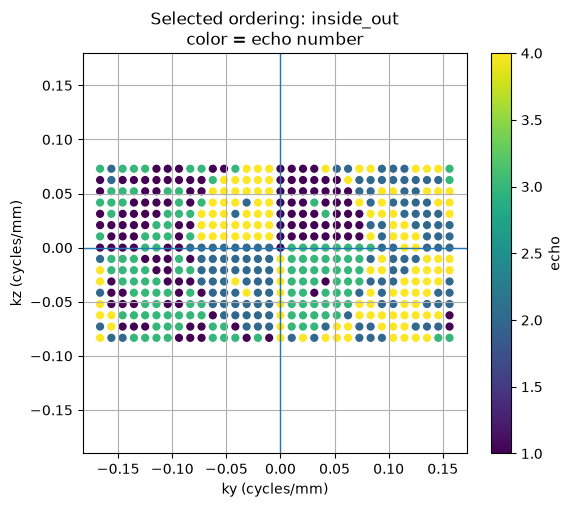

In [206]:
# Visualize selected sequence-programming table
#
# Each dot is one acquired ky-kz point.
# Color shows the echo number assigned to that point.

plot_ordering(
    sequence_table,
    f"Selected ordering: {selected_ordering_name}\ncolor = echo number",
    color_by="echo",
)

In [207]:
# Build: Assemble the 3D TSE sequence blocks
#
# This version fixes echo-to-echo drift by scheduling each echo from absolute
# echo-center targets within the shot.
#
# Target timing:
#   echo 1 ADC center -> RF90 center + 1 × echo_spacing_used
#   echo 2 ADC center -> RF90 center + 2 × echo_spacing_used
#   echo 3 ADC center -> RF90 center + 3 × echo_spacing_used
#   ...
#
# Educational 3D TSE structure:
#
#   90x
#   for each echo:
#       +Gx_pre before 180
#       delay to place 180 center correctly
#       180y
#       Gy/Gz phase encoding
#       delay to place ADC center correctly
#       Gx readout + ADC
#       Gx/Gy/Gz rewinders
#
# Spin-echo convention:
#   Physical +Gx_pre before the 180° pulse behaves like an effective
#   -kx prephaser at the readout because the 180° refocuses phase.

print("Build 3D TSE candidate sequence")
print("--------------------------------")
print("Timing mode: absolute echo-center scheduling")

seq = pp.Sequence(system)
sequence_metadata = []

# Use names defined by the timing cell, but keep robust fallbacks so this
# cell does not fail because of a duration-variable name mismatch.
echo_spacing_for_build = globals().get("echo_spacing_used", globals().get("realized_echo_spacing", echo_spacing))
combined_rewinder_duration = globals().get(
    "combined_rewinder_duration",
    globals().get("final_rewinder_duration", globals().get("rewinder_duration", prephaser_duration)),
)
combined_rewinder_duration = round_to_raster(combined_rewinder_duration)
final_rewinder_duration = combined_rewinder_duration
rewinder_duration = combined_rewinder_duration

# ----------------------------
# Helper functions
# ----------------------------

def event_duration(event):
    """Return the Pulseq event duration in seconds."""
    return float(pp.calc_duration(event))


def block_duration(*events):
    """Return the duration of a Pulseq block containing one or more events."""
    if not events:
        return 0.0
    return max(event_duration(ev) for ev in events if ev is not None)


def rf_center_offset(rf_event, nominal_duration=None):
    """Approximate RF center relative to the start of its Pulseq block."""
    delay = float(getattr(rf_event, "delay", 0.0))
    if nominal_duration is not None:
        dur = float(nominal_duration)
    elif hasattr(rf_event, "shape_dur"):
        dur = float(rf_event.shape_dur)
    elif hasattr(rf_event, "duration"):
        dur = float(rf_event.duration)
    else:
        dur = max(0.0, event_duration(rf_event) - delay)
    return delay + dur / 2


def adc_center_offset(adc_event):
    """ADC center relative to the start of the readout block."""
    delay = float(getattr(adc_event, "delay", 0.0))
    dur = float(getattr(adc_event, "duration", adc_duration))
    return delay + dur / 2


def add_delay_until(seq, current_time, target_start_time, label):
    """Delay from current_time to target_start_time, then return new time."""
    delay_needed = round_to_raster(target_start_time - current_time)
    if delay_needed < -1e-12:
        raise ValueError(
            f"Timing error before {label}: sequence is already late by "
            f"{abs(delay_needed)*1e6:.1f} us. "
            "Increase echo_spacing or shorten RF/gradient/ADC durations."
        )
    if delay_needed > 0:
        seq.add_block(pp.make_delay(delay_needed))
        current_time += delay_needed
    return current_time


# ----------------------------
# Actual block durations and centers
# ----------------------------

rf90_block_duration = event_duration(rf90)
rf180_block_duration = event_duration(rf180)
rf90_center_in_block = rf_center_offset(rf90, rf90_duration)
rf180_center_in_block = rf_center_offset(rf180, rf180_duration)

gx_pre_block_duration = event_duration(gx_pre)
readout_block_duration = block_duration(gx, adc)
adc_center_in_readout_block = adc_center_offset(adc)

# Readout rewinder.
# After the readout, kx is at +kxmax/2.
# This rewinder brings the readout direction back toward kx = 0.
gx_rewind = pp.make_trapezoid(
    channel="x",
    area=-kx_width / 2,
    duration=combined_rewinder_duration,
    system=system,
)
rewind_block_duration = max(event_duration(gx_rewind), combined_rewinder_duration, pe_duration)

print()
print("Scheduling summary")
print("------------------")
print(f"Echo spacing used       : {echo_spacing_for_build*1e3:.3f} ms")
print(f"RF90 block duration     : {rf90_block_duration*1e3:.3f} ms")
print(f"RF180 block duration    : {rf180_block_duration*1e3:.3f} ms")
print(f"Gx_pre duration         : {gx_pre_block_duration*1e3:.3f} ms")
print(f"Readout block duration  : {readout_block_duration*1e3:.3f} ms")
print(f"Rewind block duration   : {rewind_block_duration*1e3:.3f} ms")

# ----------------------------
# Build sequence shot by shot
# ----------------------------

for shot in range(n_shots):

    shot_rows = [p for p in sequence_table if p["shot"] == shot]

    if not shot_rows:
        continue

    shot_rows = sorted(shot_rows, key=lambda q: q["echo"])

    # Time within this shot, measured from the start of the shot.
    shot_time = 0.0

    # Start each TSE shot with one excitation.
    seq.add_block(rf90)
    shot_time += rf90_block_duration

    # RF90 center is the absolute timing reference within this shot.
    rf90_center_time = rf90_center_in_block

    for echo_counter, p in enumerate(shot_rows):

        echo_number = int(p["echo"])

        # Absolute targets within the shot.
        target_rf180_center = rf90_center_time + (echo_number - 0.5) * echo_spacing_for_build
        target_adc_center = rf90_center_time + echo_number * echo_spacing_for_build

        # Keep a small gap after the previous rewinder when possible.
        if echo_counter > 0 and delay_after_rewind_to_next_pre > 0:
            seq.add_block(pp.make_delay(delay_after_rewind_to_next_pre))
            shot_time += delay_after_rewind_to_next_pre

        # ------------------------------------------------------------
        # Readout prephaser BEFORE 180°
        # ------------------------------------------------------------
        seq.add_block(gx_pre)
        shot_time += gx_pre_block_duration

        # Delay so RF180 center lands at its absolute target.
        target_rf180_start = target_rf180_center - rf180_center_in_block
        shot_time = add_delay_until(
            seq=seq,
            current_time=shot_time,
            target_start_time=target_rf180_start,
            label=f"RF180 echo {echo_number}",
        )

        # Refocusing pulse.
        seq.add_block(rf180)
        shot_time += rf180_block_duration

        # ------------------------------------------------------------
        # Phase encoding AFTER 180°
        # ------------------------------------------------------------
        gy_pe, gz_pe = make_phase_encode_gradients(
            p["ky_cycles_per_m"],
            p["kz_cycles_per_m"],
        )

        if delay_180_to_pe > 0:
            seq.add_block(pp.make_delay(delay_180_to_pe))
            shot_time += delay_180_to_pe

        seq.add_block(gy_pe, gz_pe)
        shot_time += pe_duration

        # Delay so ADC center lands at its absolute target.
        target_readout_start = target_adc_center - adc_center_in_readout_block
        shot_time = add_delay_until(
            seq=seq,
            current_time=shot_time,
            target_start_time=target_readout_start,
            label=f"ADC center echo {echo_number}",
        )

        # ------------------------------------------------------------
        # Readout
        # ------------------------------------------------------------
        seq.add_block(gx, adc)
        shot_time += readout_block_duration

        # ------------------------------------------------------------
        # Rewinders
        # ------------------------------------------------------------
        gy_rewind, gz_rewind = make_phase_encode_gradients(
            -p["ky_cycles_per_m"],
            -p["kz_cycles_per_m"],
        )

        seq.add_block(gx_rewind, gy_rewind, gz_rewind)
        shot_time += rewind_block_duration

        # Metadata for reconstruction / inspection.
        sequence_metadata.append({
            "shot": int(shot),
            "echo": int(echo_number),
            "echo_time_s": float(target_adc_center - rf90_center_time),
            "scheduled_adc_center_s": float(target_adc_center),
            "iy": int(p["iy"]),
            "iz": int(p["iz"]),
            "ky_index": int(p["ky_index"]),
            "kz_index": int(p["kz_index"]),
            "ky_cycles_per_m": float(p["ky_cycles_per_m"]),
            "kz_cycles_per_m": float(p["kz_cycles_per_m"]),
            "role": p["role"],
            "ordering": selected_ordering_name,
            "sequence_acq_idx": int(p["sequence_acq_idx"]),
        })

    # TR delay after this shot.
    delay_to_TR = round_to_raster(TR - shot_time)

    if delay_to_TR < 0:
        raise ValueError(
            f"TR is too short for shot {shot}. "
            f"Increase TR or reduce ETL/echo spacing. "
            f"Approx shot time: {shot_time*1e3:.1f} ms"
        )

    if delay_to_TR > 0:
        seq.add_block(pp.make_delay(delay_to_TR))

print()
print("3D TSE candidate sequence assembled")
print("-----------------------------------")
print(f"Ordering       : {selected_ordering_name}")
print(f"Shots          : {n_shots}")
print(f"Readouts       : {len(sequence_metadata)}")
print(f"Matrix target  : {nx} × {ny} × {nz}")
print(f"Approx TR      : {TR*1e3:.1f} ms")
print(f"Echo spacing   : {echo_spacing_for_build*1e3:.3f} ms")

print()
print("First few scheduled readouts")
print("----------------------------")
print("seq | shot | echo | echo time ms | ky idx | kz idx | role")
print("----|------|------|--------------|--------|--------|------")

for item in sequence_metadata[:16]:
    print(
        f"{item['sequence_acq_idx']:3d} | "
        f"{item['shot']:4d} | "
        f"{item['echo']:4d} | "
        f"{item['echo_time_s']*1e3:12.3f} | "
        f"{item['ky_index']:6d} | "
        f"{item['kz_index']:6d} | "
        f"{item['role']}"
    )

Build 3D TSE candidate sequence
--------------------------------
Timing mode: absolute echo-center scheduling

Scheduling summary
------------------
Echo spacing used       : 10.000 ms
RF90 block duration     : 0.270 ms
RF180 block duration    : 0.420 ms
Gx_pre duration         : 1.000 ms
Readout block duration  : 3.222 ms
Rewind block duration   : 1.000 ms

3D TSE candidate sequence assembled
-----------------------------------
Ordering       : inside_out
Shots          : 128
Readouts       : 512
Matrix target  : 64 × 32 × 16
Approx TR      : 1000.0 ms
Echo spacing   : 10.000 ms

First few scheduled readouts
----------------------------
seq | shot | echo | echo time ms | ky idx | kz idx | role
----|------|------|--------------|--------|--------|------
  0 |    0 |    1 |       10.000 |      0 |      0 | center
  1 |    0 |    2 |       20.000 |     -1 |      0 | near-center
  2 |    0 |    3 |       30.000 |      1 |      0 | near-center
  3 |    0 |    4 |       40.000 |      0 |    

In [208]:
# Check: Pulseq timing validation

ok, error_report = seq.check_timing()
print("Pulseq timing validation")
print("------------------------")
if ok:
    print("PASS: Pulseq timing check passed.")
else:
    print("FAIL: Pulseq timing check reported errors.")
    for line in error_report[:20]:
        print(line)


Pulseq timing validation
------------------------
FAIL: Pulseq timing check reported errors.
namespace(block=7, event='block', field='duration', value=0.0032215999999999994, value_rounded=0.00322, error=1.5999999999991715e-06, raster='block_duration_raster', error_type='RASTER')
namespace(block=7, event='gx', field='flat_time', value=0.0030015999999999997, value_rounded=0.003, error=1.5999999999996052e-06, raster='grad_raster_time', error_type='RASTER')
namespace(block=14, event='block', field='duration', value=0.0032215999999999994, value_rounded=0.00322, error=1.5999999999991715e-06, raster='block_duration_raster', error_type='RASTER')
namespace(block=14, event='gx', field='flat_time', value=0.0030015999999999997, value_rounded=0.003, error=1.5999999999996052e-06, raster='grad_raster_time', error_type='RASTER')
namespace(block=21, event='block', field='duration', value=0.0032215999999999994, value_rounded=0.00322, error=1.5999999999991715e-06, raster='block_duration_raster', error_ty

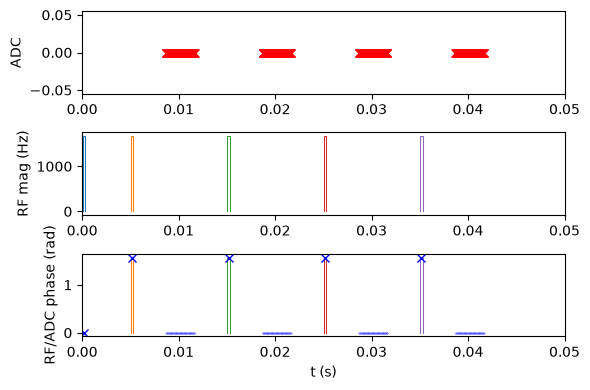

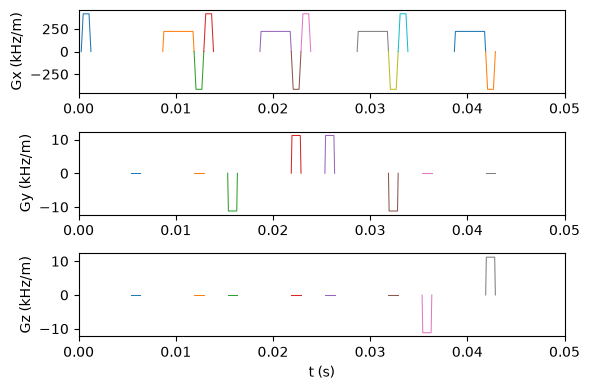

In [209]:
# Visualize: 3D TSE timing diagram
# Plot only the first part of the sequence so the figure remains readable.

try:
    seq.plot(time_range=(0, min(TR * 1.2, 0.05)))
except Exception as exc:
    print("Sequence plot failed, but the sequence object may still be valid.")
    print("Reason:", repr(exc))


In [210]:
# Inspect: First shot and first echo train

first_shot = min(p["shot"] for p in sequence_metadata)
rows = [p for p in sequence_metadata if p["shot"] == first_shot]

print("First shot inspection")
print("---------------------")
print(f"Shot {first_shot} has {len(rows)} readouts")
print("echo | ky_idx | kz_idx | ky cyc/mm | kz cyc/mm | role")
print("-----|--------|--------|-----------|-----------|------")
for p in rows:
    print(
        f"{p['echo']:4d} | {p['ky_index']:6d} | {p['kz_index']:6d} | "
        f"{p['ky_cycles_per_m']/1000:9.4f} | {p['kz_cycles_per_m']/1000:9.4f} | {p['role']}"
    )


First shot inspection
---------------------
Shot 0 has 4 readouts
echo | ky_idx | kz_idx | ky cyc/mm | kz cyc/mm | role
-----|--------|--------|-----------|-----------|------
   1 |      0 |      0 |    0.0000 |    0.0000 | center
   2 |     -1 |      0 |   -0.0104 |    0.0000 | near-center
   3 |      1 |      0 |    0.0104 |    0.0000 | near-center
   4 |      0 |     -1 |    0.0000 |   -0.0104 | near-center


In [211]:
# Inspect: Central k-space shot and TEeff echo

center_rows = [p for p in sequence_metadata if p["ky_index"] == 0 and p["kz_index"] == 0]
print("Central k-space inspection")
print("--------------------------")
if center_rows:
    c = center_rows[0]
    print(f"Center ky-kz acquired in shot {c['shot']}, echo {c['echo']}")
    print(f"Echo time estimate: {c['echo_time_s'] * 1e3:.1f} ms")
    print(f"TEeff target      : {TEeff_target*1e3:.1f} ms")
else:
    print("WARNING: selected table does not include ky=0, kz=0.")

Central k-space inspection
--------------------------
Center ky-kz acquired in shot 0, echo 1
Echo time estimate: 10.0 ms
TEeff target      : 40.0 ms


## Simulate before writing the `.seq` file

A useful engineering habit is:

```text
Design → build candidate → simulate / inspect → export only when ready
```

The simulation below uses a BrainWeb anatomical object when available and a synthetic brain-like object otherwise. The default reconstruction is a fast Fourier sanity check of the selected ky-kz coverage and echo weighting.


In [212]:
# Load: BrainWeb anatomical volume

try:
    import brainweb_dl as bwdl
    HAVE_BRAINWEB_DL = True
except Exception as exc:
    HAVE_BRAINWEB_DL = False
    BRAINWEB_DL_IMPORT_ERROR = exc

print("BrainWeb volume setup")
print("---------------------")
print("brainweb_dl:", "OK" if HAVE_BRAINWEB_DL else f"not available: {BRAINWEB_DL_IMPORT_ERROR!r}")

brainweb_contrast = "T1"

if HAVE_BRAINWEB_DL:
    try:
        bw_vol = bwdl.get_mri(sub_id=5, contrast=brainweb_contrast)
        bw_vol = np.asarray(bw_vol, dtype=np.float32)
        print("Loaded BrainWeb volume")
        print("  shape:", bw_vol.shape)
        print("  dtype:", bw_vol.dtype)
    except Exception as exc:
        print("BrainWeb download/load failed. Using synthetic object instead.")
        print("Reason:", repr(exc))
        HAVE_BRAINWEB_DL = False

if not HAVE_BRAINWEB_DL:
    zz, yy, xx = np.meshgrid(
        np.linspace(-1, 1, 96),
        np.linspace(-1, 1, 128),
        np.linspace(-1, 1, 128),
        indexing="ij",
    )
    outer = ((xx/0.70)**2 + (yy/0.92)**2 + (zz/0.78)**2) <= 1
    inner = ((xx/0.52)**2 + (yy/0.70)**2 + (zz/0.55)**2) <= 1
    ventricles = (((xx+0.16)/0.10)**2 + (yy/0.18)**2 + (zz/0.20)**2 <= 1) | (((xx-0.16)/0.10)**2 + (yy/0.18)**2 + (zz/0.20)**2 <= 1)
    bw_vol = np.zeros_like(xx, dtype=np.float32)
    bw_vol[outer] = 0.55
    bw_vol[inner] = 0.85
    bw_vol[ventricles] = 0.20
    print("Created synthetic 3D brain-like volume")
    print("  shape:", bw_vol.shape)


BrainWeb volume setup
---------------------
brainweb_dl: OK
Loaded BrainWeb volume
  shape: (181, 256, 256)
  dtype: float32


Prepared 3D simulation object
-----------------------------
Target shape [nz, ny, nx]: (16, 32, 64)
Min/max: 0.0 0.5573140382766724


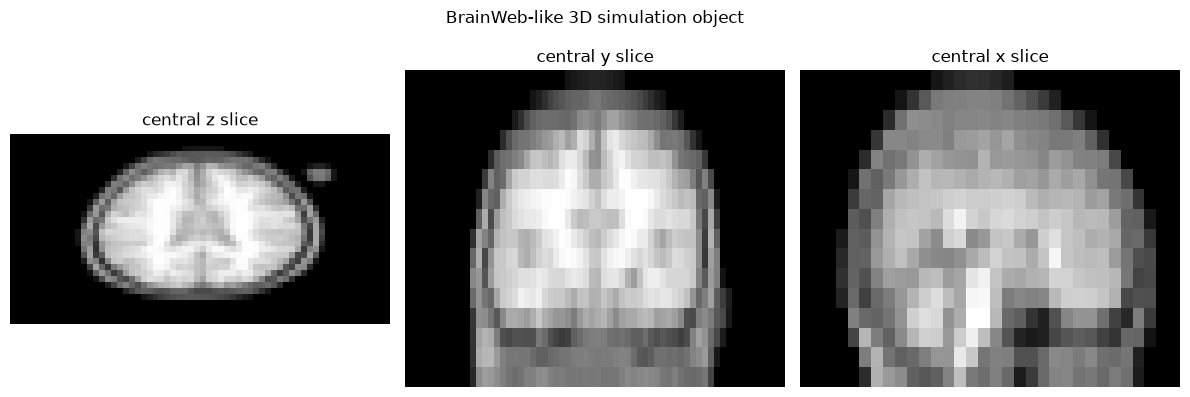

In [213]:
# Prepare: Resize BrainWeb volume to the 3D matrix
# Resizing keeps the whole brain visible. This is a teaching object, not quantitative anatomy.

try:
    from skimage.transform import resize
    HAVE_SKIMAGE_RESIZE = True
except Exception as exc:
    HAVE_SKIMAGE_RESIZE = False
    SKIMAGE_IMPORT_ERROR = exc

vol = np.asarray(bw_vol, dtype=np.float32)
vol = vol - np.nanmin(vol)
if np.nanmax(vol) > 0:
    vol = vol / np.nanmax(vol)

target_shape = (nz, ny, nx)  # [kz/image z, y, x]

if HAVE_SKIMAGE_RESIZE:
    vol_resized = resize(
        vol,
        output_shape=target_shape,
        order=1,
        mode="constant",
        cval=0.0,
        anti_aliasing=True,
        preserve_range=True,
    ).astype(np.float32)
else:
    print("skimage.resize unavailable; using simple center crop/pad.")
    print("Reason:", repr(SKIMAGE_IMPORT_ERROR))
    def center_crop_or_pad_3d(arr, out_shape):
        out = np.zeros(out_shape, dtype=np.float32)
        in_shape = arr.shape
        copy = tuple(min(i, o) for i, o in zip(in_shape, out_shape))
        in0 = tuple(max(0, (i - c)//2) for i, c in zip(in_shape, copy))
        out0 = tuple(max(0, (o - c)//2) for o, c in zip(out_shape, copy))
        out[out0[0]:out0[0]+copy[0], out0[1]:out0[1]+copy[1], out0[2]:out0[2]+copy[2]] = arr[in0[0]:in0[0]+copy[0], in0[1]:in0[1]+copy[1], in0[2]:in0[2]+copy[2]]
        return out
    vol_resized = center_crop_or_pad_3d(vol, target_shape)

PD_3d = vol_resized
PD_3d[PD_3d < 0.04] = 0.0

print("Prepared 3D simulation object")
print("-----------------------------")
print("Target shape [nz, ny, nx]:", PD_3d.shape)
print("Min/max:", float(PD_3d.min()), float(PD_3d.max()))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(PD_3d[nz//2, :, :], origin="lower", cmap="gray")
axes[0].set_title("central z slice")
axes[1].imshow(PD_3d[:, ny//2, :], origin="lower", cmap="gray", aspect="auto")
axes[1].set_title("central y slice")
axes[2].imshow(PD_3d[:, :, nx//2], origin="lower", cmap="gray", aspect="auto")
axes[2].set_title("central x slice")
for ax in axes:
    ax.axis("off")
plt.suptitle("BrainWeb-like 3D simulation object")
plt.tight_layout()
plt.show()


In [214]:
# Prepare: Build MRZero 3D simulation data if available
# The next cell uses a fast Fourier sanity check by default.

if HAVE_MRZERO and HAVE_TORCH:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    z = torch.linspace(-fov_z_m/2, fov_z_m/2, nz, dtype=torch.float32)
    y = torch.linspace(-fov_y_m/2, fov_y_m/2, ny, dtype=torch.float32)
    x = torch.linspace(-fov_x_m/2, fov_x_m/2, nx, dtype=torch.float32)
    Z, Y, X = torch.meshgrid(z, y, x, indexing="ij")

    PD_t = torch.tensor(PD_3d, dtype=torch.float32)
    mask3d = PD_t > 0.05

    flat_pos = torch.stack([X[mask3d], Y[mask3d], Z[mask3d]], dim=-1)
    flat_PD = PD_t[mask3d]
    flat_T1 = torch.ones_like(flat_PD) * 1.0
    flat_T2 = torch.ones_like(flat_PD) * 0.080
    ones = torch.ones_like(flat_PD)
    zeros = torch.zeros_like(flat_PD)

    mrzero_phantom_3d = mr0.CustomVoxelPhantom(
        pos=flat_pos.to(device),
        PD=flat_PD.to(device),
        T1=flat_T1.to(device),
        T2=flat_T2.to(device),
        T2dash=(30e-3 * ones).to(device),
        D=zeros.to(device),
        B0=zeros.to(device),
        B1=ones.to(device),
        voxel_size=float(min(fov_x_m/nx, fov_y_m/ny, fov_z_m/nz)),
        voxel_shape="box",
    )

    try:
        mrzero_sim_data_3d = mrzero_phantom_3d.build()
        print("MRZero 3D simulation data built.")
        print("  active spins:", int(flat_PD.numel()))
        print("  device      :", device)
        print("  sim data    :", type(mrzero_sim_data_3d))
    except Exception as exc:
        mrzero_sim_data_3d = None
        print("MRZero phantom was created, but build() failed.")
        print("Reason:", repr(exc))
else:
    mrzero_phantom_3d = None
    mrzero_sim_data_3d = None
    print("MRZero or Torch not available. Skipping MRZero 3D phantom build.")


MRZero 3D simulation data built.
  active spins: 11368
  device      : cpu
  sim data    : <class 'MRzeroCore.phantom.sim_data.SimData'>


In [215]:
# Run: Simulate the candidate 3D TSE sequence
# Fast Fourier sanity-check simulation.

kspace_full = np.fft.fftshift(np.fft.fftn(np.fft.ifftshift(PD_3d)))
kspace_acq = np.zeros_like(kspace_full, dtype=np.complex64)
coverage_mask = np.zeros((nz, ny), dtype=bool)
echo_number_map = np.zeros((nz, ny), dtype=int)

for p in sequence_table:
    iy = int(p["iy"])
    iz = int(p["iz"])
    echo = int(p["echo"])
    weight = float(np.exp(-(echo * echo_spacing) / T2_assumed))
    kspace_acq[iz, iy, :] = kspace_full[iz, iy, :] * weight
    coverage_mask[iz, iy] = True
    echo_number_map[iz, iy] = echo

print("Fourier sanity-check simulation")
print("-------------------------------")
print(f"Ordering          : {selected_ordering_name}")
print(f"Acquired ky-kz    : {coverage_mask.sum()} / {coverage_mask.size}")
print(f"Coverage fraction : {coverage_mask.mean():.3f}")
print(f"Echo weight model : exp(-TE/T2), T2 = {T2_assumed*1e3:.1f} ms")


Fourier sanity-check simulation
-------------------------------
Ordering          : inside_out
Acquired ky-kz    : 512 / 512
Coverage fraction : 1.000
Echo weight model : exp(-TE/T2), T2 = 80.0 ms


In [216]:
# Reconstruct: Reshape k-space and restore ky-kz order

recon_3d = np.fft.fftshift(np.fft.ifftn(np.fft.ifftshift(kspace_acq)))
recon_mag = np.abs(recon_3d)
if recon_mag.max() > 0:
    recon_mag = recon_mag / recon_mag.max()

print("Reconstruction complete")
print("-----------------------")
print("recon shape:", recon_mag.shape)
print("min/max    :", float(recon_mag.min()), float(recon_mag.max()))


Reconstruction complete
-----------------------
recon shape: (16, 32, 64)
min/max    : 9.514784128631456e-11 1.0


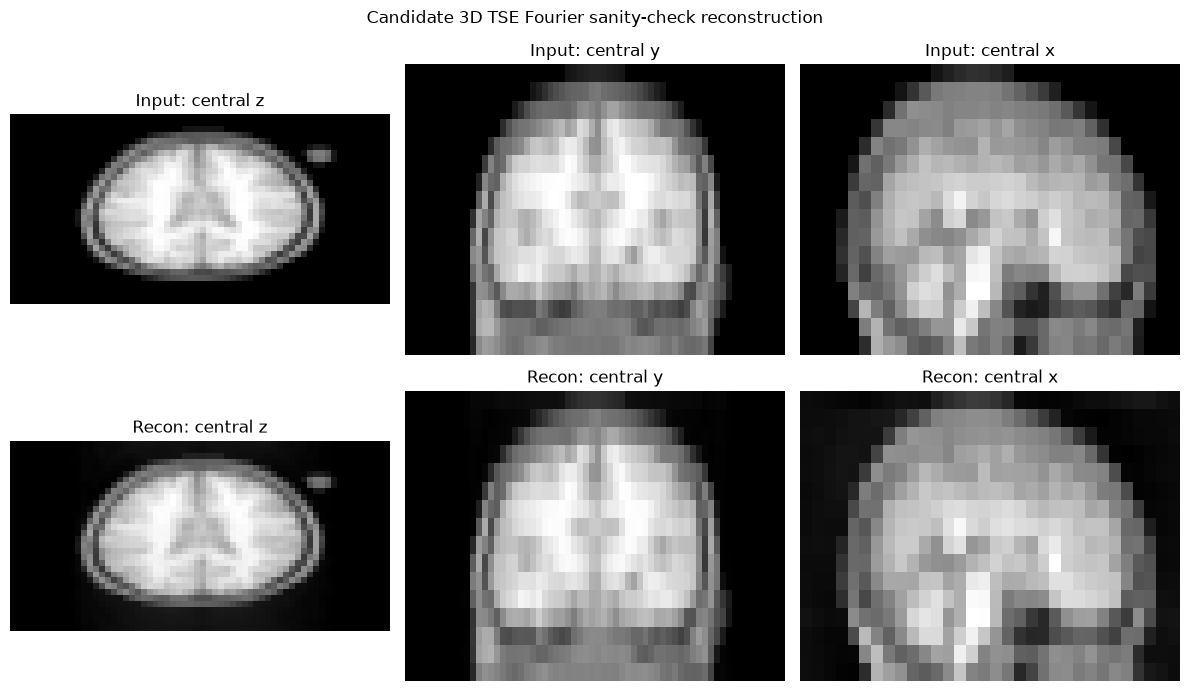

In [217]:
# Visualize: Central slices of the reconstructed 3D volume

fig, axes = plt.subplots(2, 3, figsize=(12, 7))

axes[0, 0].imshow(PD_3d[nz//2, :, :], origin="lower", cmap="gray")
axes[0, 0].set_title("Input: central z")
axes[0, 1].imshow(PD_3d[:, ny//2, :], origin="lower", cmap="gray", aspect="auto")
axes[0, 1].set_title("Input: central y")
axes[0, 2].imshow(PD_3d[:, :, nx//2], origin="lower", cmap="gray", aspect="auto")
axes[0, 2].set_title("Input: central x")

axes[1, 0].imshow(recon_mag[nz//2, :, :], origin="lower", cmap="gray")
axes[1, 0].set_title("Recon: central z")
axes[1, 1].imshow(recon_mag[:, ny//2, :], origin="lower", cmap="gray", aspect="auto")
axes[1, 1].set_title("Recon: central y")
axes[1, 2].imshow(recon_mag[:, :, nx//2], origin="lower", cmap="gray", aspect="auto")
axes[1, 2].set_title("Recon: central x")

for ax in axes.ravel():
    ax.axis("off")

plt.suptitle("Candidate 3D TSE Fourier sanity-check reconstruction")
plt.tight_layout()
plt.show()


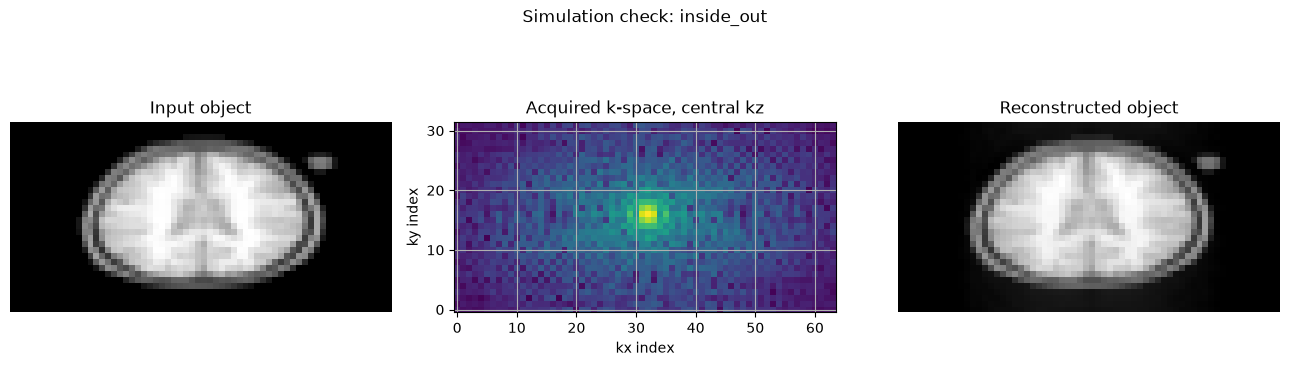

In [218]:
# Compare: BrainWeb input versus simulated 3D TSE output

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(PD_3d[nz//2], origin="lower", cmap="gray")
axes[0].set_title("Input object")
axes[0].axis("off")

axes[1].imshow(np.log1p(np.abs(kspace_acq[nz//2])), origin="lower")
axes[1].set_title("Acquired k-space, central kz")
axes[1].set_xlabel("kx index")
axes[1].set_ylabel("ky index")

axes[2].imshow(recon_mag[nz//2], origin="lower", cmap="gray")
axes[2].set_title("Reconstructed object")
axes[2].axis("off")

plt.suptitle(f"Simulation check: {selected_ordering_name}")
plt.tight_layout()
plt.show()


In [219]:
# Decision: Is this sequence ready to export?

APPROVED_FOR_EXPORT = False

print("Export decision")
print("---------------")
print("APPROVED_FOR_EXPORT:", APPROVED_FOR_EXPORT)
print()
print("Set APPROVED_FOR_EXPORT = True only after:")
print("  1. Pulseq timing check passes")
print("  2. central ky-kz is acquired at the intended echo")
print("  3. k-space coverage/order looks correct")
print("  4. simulation output is acceptable")


Export decision
---------------
APPROVED_FOR_EXPORT: False

Set APPROVED_FOR_EXPORT = True only after:
  1. Pulseq timing check passes
  2. central ky-kz is acquired at the intended echo
  3. k-space coverage/order looks correct
  4. simulation output is acceptable


In [220]:
# Write: Export the approved 3D TSE .seq file

out_file = f"tse_3d_{selected_ordering_name}_{nx}x{ny}x{nz}_ETL{ETL}.seq"

if not APPROVED_FOR_EXPORT:
    print("Not exporting yet.")
    print("Set APPROVED_FOR_EXPORT = True in the previous cell after inspection.")
else:
    ok, error_report = seq.check_timing()
    if not ok:
        print("Timing check failed. Not writing sequence.")
        for line in error_report[:20]:
            print(line)
    else:
        seq.write(out_file)
        print(f"Saved sequence file: {out_file}")
        print(f"Absolute path      : {Path(out_file).resolve()}")
        print(f"File size          : {Path(out_file).stat().st_size} bytes")


Not exporting yet.
Set APPROVED_FOR_EXPORT = True in the previous cell after inspection.


In [221]:
# Verify: Reload the exported .seq file

if Path(out_file).exists():
    seq_reloaded = pp.Sequence(system)
    try:
        seq_reloaded.read(out_file)
        ok_reload, report_reload = seq_reloaded.check_timing()
        print("Reloaded exported sequence.")
        print("Timing check after reload:", "PASS" if ok_reload else "FAIL")
    except Exception as exc:
        print("Reload failed.")
        print("Reason:", repr(exc))
else:
    print("No exported .seq file found yet:", out_file)


No exported .seq file found yet: tse_3d_inside_out_64x32x16_ETL4.seq


## Scan notes: What to check before running on the scanner

Before scanner execution:

- confirm the scanner center frequency `f0`,
- confirm RF pulse widths from the RF calibration notebook,
- verify RF power and duty-cycle safety limits,
- confirm gradient amplitude and slew constraints,
- start with a low matrix / short ETL debug scan,
- check that the selected ordering is intentional,
- confirm whether elliptical filtering is allowed for the intended test,
- save protocol parameters and the generated `ky_kz_table` with the data.


## Scan notes: What to record after acquisition

After acquisition, record:

- sequence filename,
- `nx`, `ny`, `nz`, FOV, TR, ETL, echo spacing, TEeff,
- selected ordering name,
- whether elliptical filtering was used,
- number of acquired ky-kz points,
- scan duration,
- center-frequency and RF calibration values,
- any gradient amplifier warnings or timing errors,
- reconstruction command and output filename.


## Assignment: Change ETL and explain the SNR / contrast / time tradeoff

The default notebook uses:

```python
ETL = 4
echo_spacing = 10e-3
TEeff_target = 40e-3
```

This is a clean textbook example because echo 4 lands at 40 ms.

For the assignment, try:

```python
ETL = 8
ETL = 16
```

For each case, answer:

1. How many shots are needed?
2. What is the estimated scan time?
3. Which echo samples central k-space?
4. How much signal decay occurs by the last echo?
5. Does the requested 10 ms echo spacing remain feasible?
6. If not, what would you change first: ADC duration, FOV, prephaser duration, PE duration, or echo spacing?
7. At 0.2516 T, which ETL would you choose for a first debug scan and why?

Teaching point:

```text
ETL improves scan efficiency, but timing feasibility and late-echo SNR matter.
```


## Assignment: Compare inside-out, linear, and TEeff-optimized ordering

For each ordering:

1. plot the acquisition order,
2. identify the shot and echo of central k-space,
3. explain whether the ordering is better suited for T1w/debug or T2w contrast,
4. comment on gradient polarity changes and jumps in ky-kz.


## Assignment: Apply elliptical filtering and quantify scan-time savings

Change the elliptical threshold or matrix size and report:

```text
full ky-kz points
acquired ky-kz points
skipped ky-kz points
scan-time savings
visual difference in reconstructed slices
```

Discussion question:

> What anatomy or image features are most affected when ky-kz corners are skipped?


## Final takeaway: 3D TSE is sequence scheduling in ky-kz space

A 3D TSE sequence is not just “2D TSE repeated.”

It is a scheduling problem:

```text
Choose ETL
Choose TEeff
Choose ky-kz coverage
Choose ky-kz ordering
Assign each ky-kz point to a shot and echo
Build the sequence
Simulate / inspect
Export when ready
```

That is the programming bridge from lecture concepts to scanner-facing sequence files.
